In [161]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder


In [162]:
df = pd.read_csv("./AmesHousing.csv")

## 1. Understanding the dataset

In [163]:
df.shape

(2930, 82)

In [164]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [165]:
df.head(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
5,6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
6,7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
7,8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
8,9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500
9,10,527162130,60,RL,60.0,7500,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,189000


In [166]:
df.duplicated().sum()

np.int64(0)

In [167]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [168]:
missing_values = df.isnull().sum()
print(missing_values.to_string())

Order                 0
PID                   0
MS SubClass           0
MS Zoning             0
Lot Frontage        490
Lot Area              0
Street                0
Alley              2732
Lot Shape             0
Land Contour          0
Utilities             0
Lot Config            0
Land Slope            0
Neighborhood          0
Condition 1           0
Condition 2           0
Bldg Type             0
House Style           0
Overall Qual          0
Overall Cond          0
Year Built            0
Year Remod/Add        0
Roof Style            0
Roof Matl             0
Exterior 1st          0
Exterior 2nd          0
Mas Vnr Type       1775
Mas Vnr Area         23
Exter Qual            0
Exter Cond            0
Foundation            0
Bsmt Qual            80
Bsmt Cond            80
Bsmt Exposure        83
BsmtFin Type 1       80
BsmtFin SF 1          1
BsmtFin Type 2       81
BsmtFin SF 2          1
Bsmt Unf SF           1
Total Bsmt SF         1
Heating               0
Heating QC      

In [169]:
df.isnull().sum().sum()

np.int64(15749)

In [170]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [171]:
df.describe(include="all")

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2930,2440.000000,2930.000000,2930,198,2930,2930,...,2930.000000,13,572,106,2930.000000,2930.000000,2930.000000,2930,2930,2930.000000
unique,NaN,NaN,NaN,7,NaN,NaN,2,2,4,4,...,NaN,4,4,5,NaN,NaN,NaN,10,6,NaN
top,NaN,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,...,NaN,Ex,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,NaN,2273,NaN,NaN,2918,120,1859,2633,...,NaN,4,330,95,NaN,NaN,NaN,2536,2413,NaN
mean,1465.50000,7.144645e+08,57.387372,NaN,69.224590,10147.921843,NaN,NaN,NaN,NaN,...,2.243345,NaN,NaN,NaN,50.635154,6.216041,2007.790444,NaN,NaN,180796.060068
std,845.96247,1.887308e+08,42.638025,NaN,23.365335,7880.017759,NaN,NaN,NaN,NaN,...,35.597181,NaN,NaN,NaN,566.344288,2.714492,1.316613,NaN,NaN,79886.692357
min,1.00000,5.263011e+08,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,1.000000,2006.000000,NaN,NaN,12789.000000
25%,733.25000,5.284770e+08,20.000000,NaN,58.000000,7440.250000,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,4.000000,2007.000000,NaN,NaN,129500.000000
50%,1465.50000,5.354536e+08,50.000000,NaN,68.000000,9436.500000,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,6.000000,2008.000000,NaN,NaN,160000.000000
75%,2197.75000,9.071811e+08,70.000000,NaN,80.000000,11555.250000,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,8.000000,2009.000000,NaN,NaN,213500.000000


## 2. Handling the missing values

In [172]:
dfcopy = df.copy()

dfcopy.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


Dropping the missing values for the columns below because the count of missing values is very low.
- BsmtFin SF 1
- BsmtFin SF 2
- Bsmt Unf SF
- Total Bsmt SF
- Electrical
- Bsmt Full Bath
- Bsmt Half Bath
- Garage Cars
- Garage Area
- Mas Vnr Area

In [173]:
dfcopy.isnull().sum().sum()

np.int64(15749)

In [174]:
col_to_drop_null = ["BsmtFin SF 1", "BsmtFin SF 2", "Bsmt Unf SF", "Total Bsmt SF", "Electrical", 
               "Bsmt Full Bath", "Bsmt Half Bath", "Garage Cars", "Garage Area", "Mas Vnr Area"]

dfcopy = df.dropna(subset=col_to_drop_null)

In [175]:
dfcopy.isnull().sum().sum()

np.int64(15547)

### Analyzing the rest of the numerical columns to fill the missing values

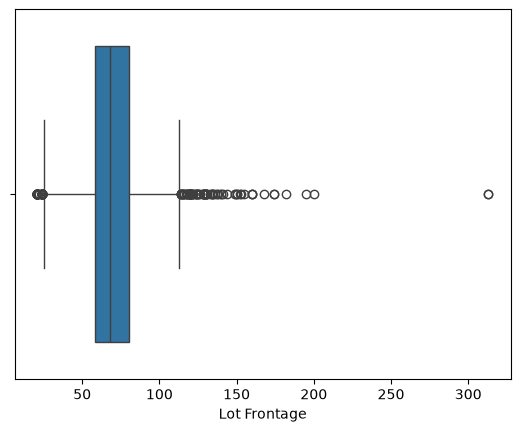

In [176]:
sns.boxplot(x=dfcopy["Lot Frontage"])

plt.show()

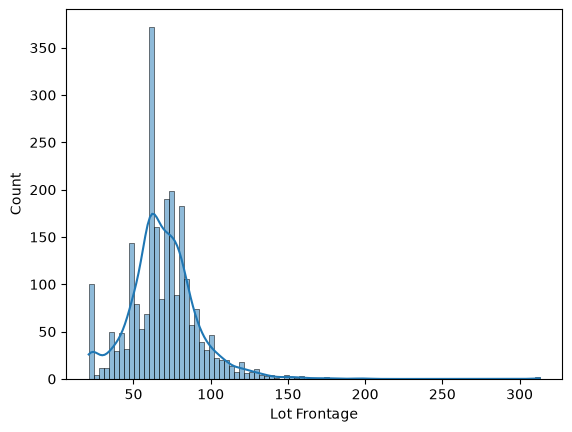

In [177]:
sns.histplot(dfcopy["Lot Frontage"], kde=True)

plt.show()

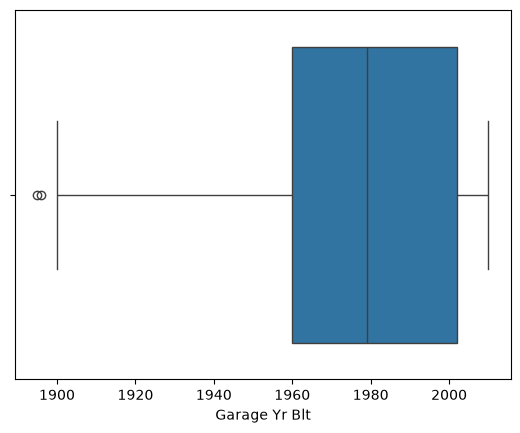

In [178]:
sns.boxplot(x=dfcopy["Garage Yr Blt"])

plt.show()

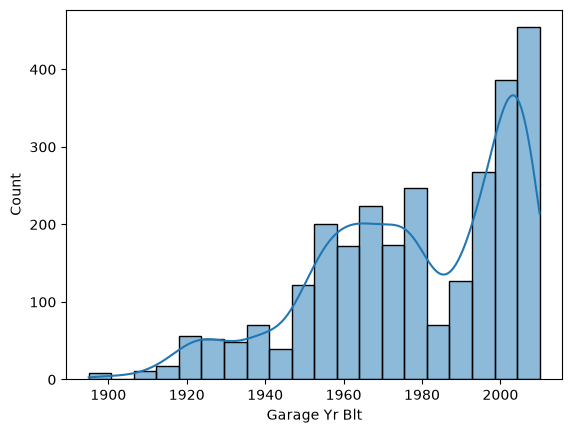

In [179]:
sns.histplot(dfcopy["Garage Yr Blt"], kde=True)

plt.show()

Choosing median for both the columns because both the columns have very skewed values and median is a better fit for skewed values.

In [180]:
dfcopy["Lot Frontage"] = dfcopy["Lot Frontage"].fillna(dfcopy["Lot Frontage"].median())

dfcopy["Lot Frontage"].isnull().sum()

np.int64(0)

In [181]:
dfcopy["Garage Yr Blt"] = dfcopy["Garage Yr Blt"].fillna(dfcopy["Garage Yr Blt"].median())

dfcopy["Garage Yr Blt"].isnull().sum()

np.int64(0)

### Handling the missing values in categorical columns for the columns having very less number of missing values < 500
- Mas Vnr Area
- Bsmt Qual
- Bsmt Cond
- Bsmt Exposure
- BsmtFin Type 1
- BsmtFin SF 1
- BsmtFin Type 2 
- BsmtFin SF 2
- Bsmt Unf SF
- Total Bsmt SF
- Electrical
- Bsmt Full Bath
- Bsmt Half Bath
- Garage Type
- Garage Finish
- Garage Cars
- Garage Area
- Garage Qual
- Garage Cond

In [182]:
low_missing = ["Mas Vnr Area", "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", 
               "BsmtFin SF 1", "BsmtFin Type 2", "BsmtFin SF 2", "Bsmt Unf SF", "Total Bsmt SF", 
               "Electrical", "Bsmt Full Bath", "Bsmt Half Bath", "Garage Type", "Garage Finish", 
               "Garage Cars", "Garage Area", "Garage Qual", "Garage Cond"]

for col in low_missing:
    dfcopy[col] = dfcopy[col].fillna(dfcopy[col].mode()[0])

### Creating a new category and flag for missing values for the columns having moderate number of missing values
- Fireplace Qu
- Mas Vnr Type

In [183]:
filling_col = ["Fireplace Qu", "Mas Vnr Type"]

for col in filling_col:
    dfcopy[f"{col}_is_missing"] = dfcopy[col].isnull().astype(int)
    dfcopy[col] = dfcopy[col].fillna("Unknown")

In [184]:
print(dfcopy["Fireplace Qu"].isnull().sum())
dfcopy["Mas Vnr Type"].isnull().sum()

0


np.int64(0)

### Dropping the below column because they have too many missing values > 2000 so very less data is inferred from this
- Misc Feature
- Fence
- Pool QC
- Alley

In [185]:
drop_col = ["Misc Feature", "Fence", "Pool QC", "Alley"]

dfcopy = dfcopy.drop(columns=drop_col)

In [186]:
dfcopy.shape

(2903, 80)

## Fixing the outliers in the numerical columns

In [187]:
numerical_columns = dfcopy.select_dtypes(include=["int64", "float64"]).columns

numerical_columns = numerical_columns.drop(["Order", "PID"])

print(numerical_columns)

Index(['MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area',
       'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area',
       'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath',
       'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces',
       'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF',
       'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch',
       'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice',
       'Fireplace Qu_is_missing', 'Mas Vnr Type_is_missing'],
      dtype='str')


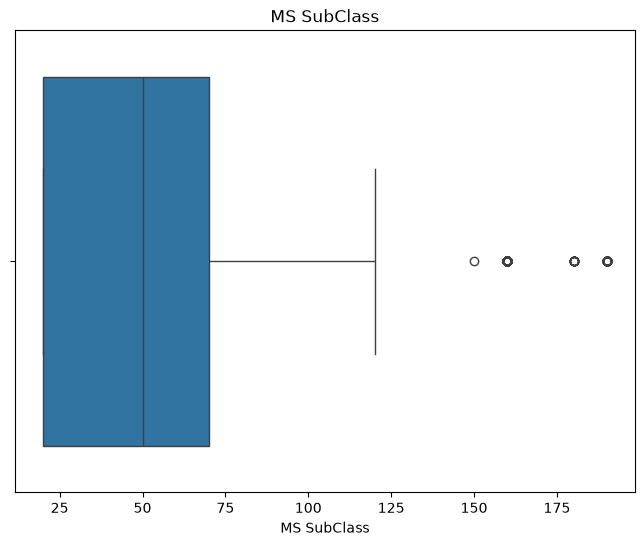

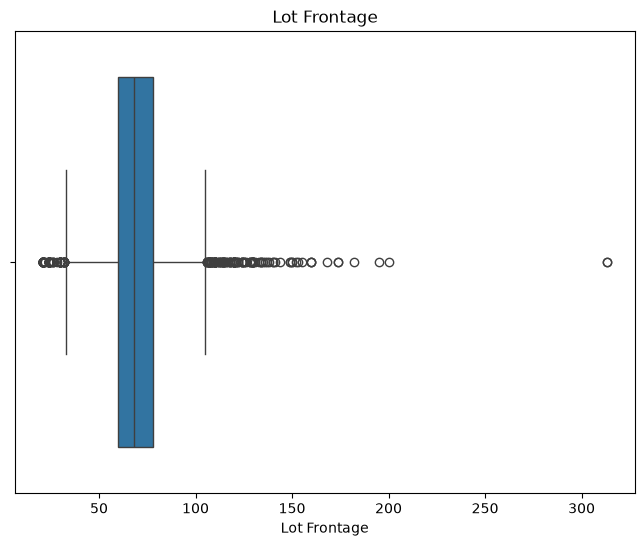

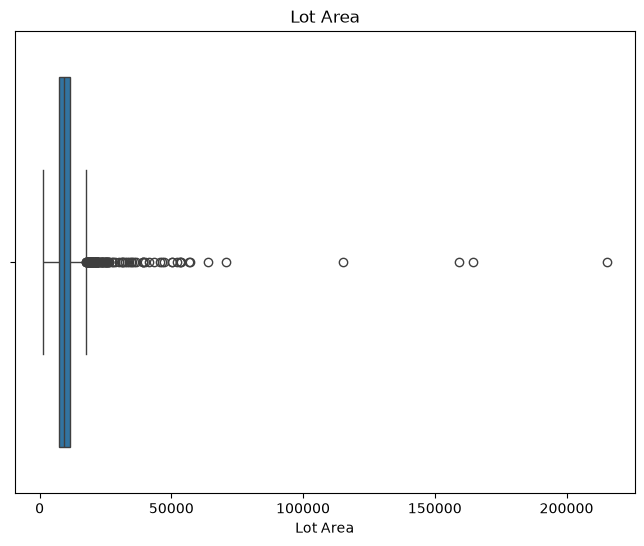

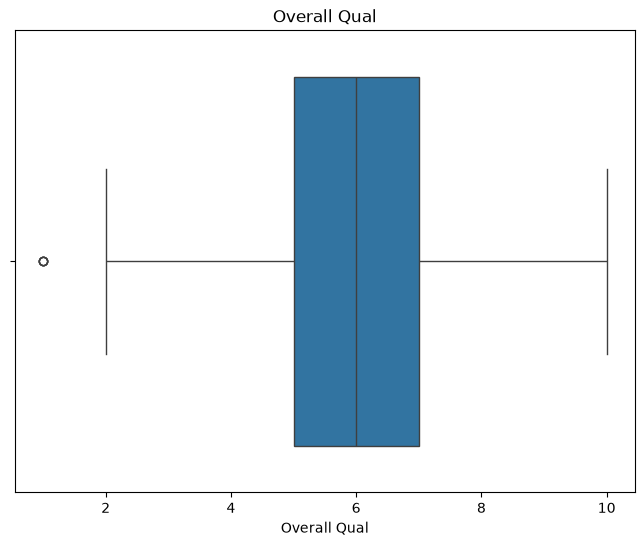

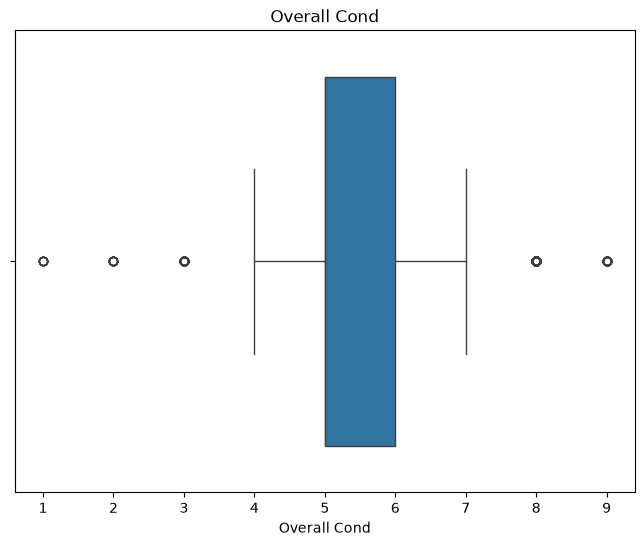

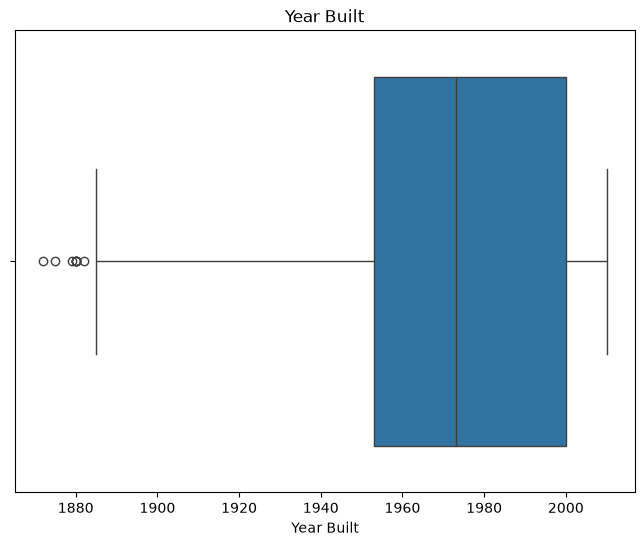

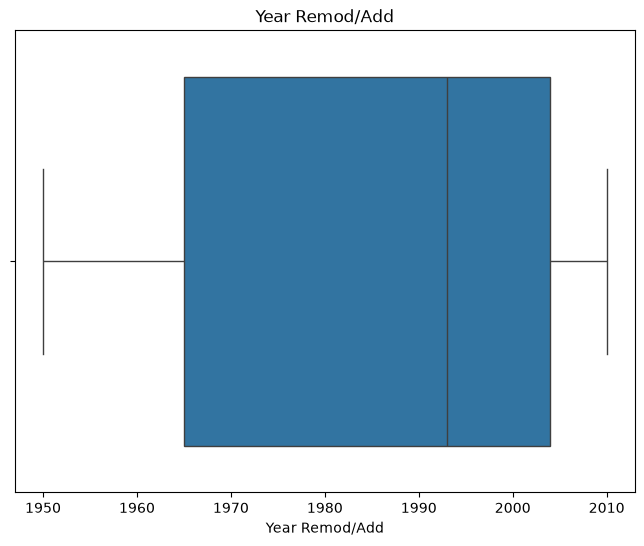

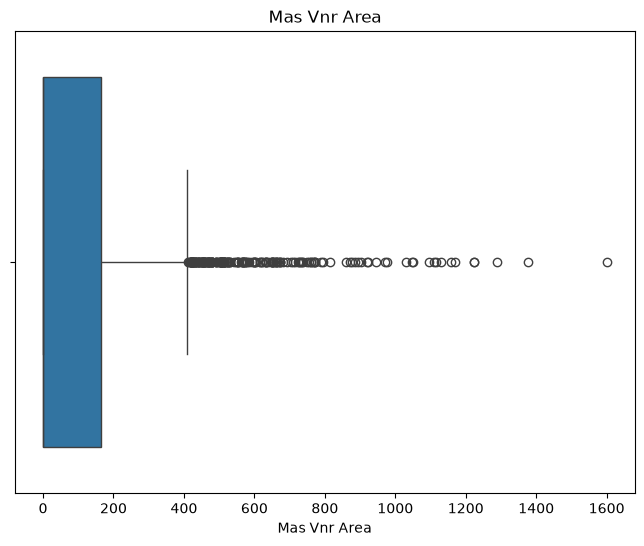

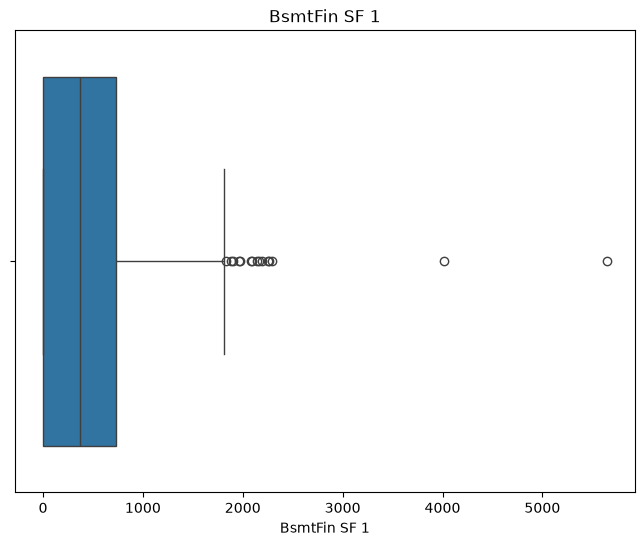

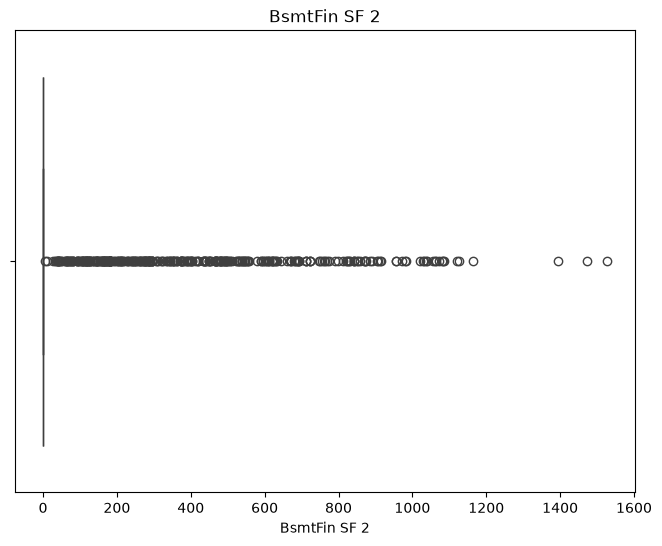

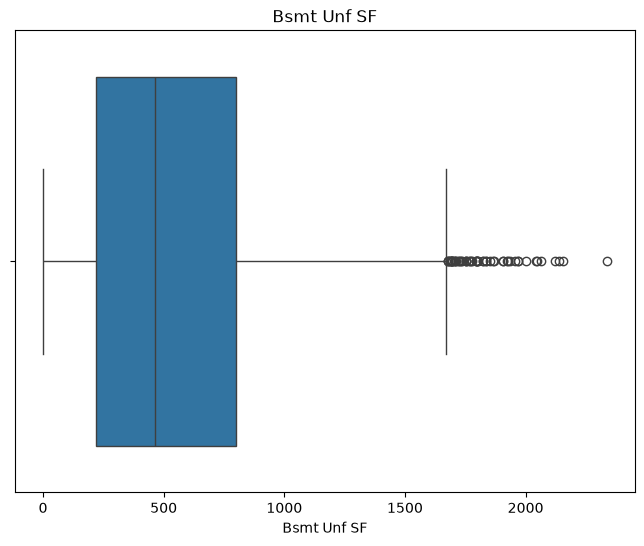

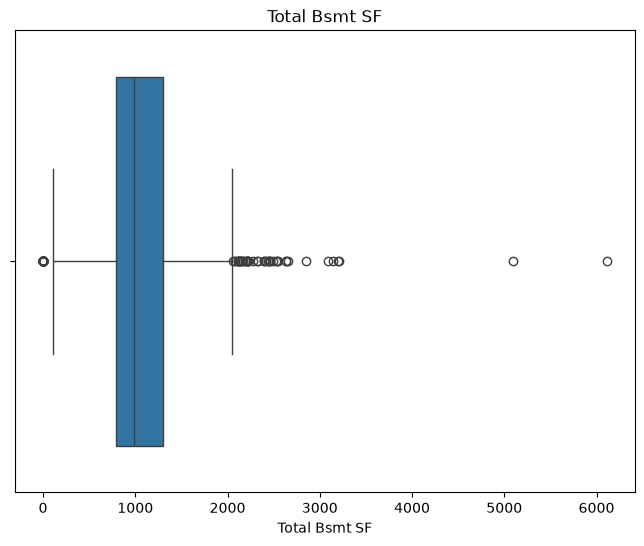

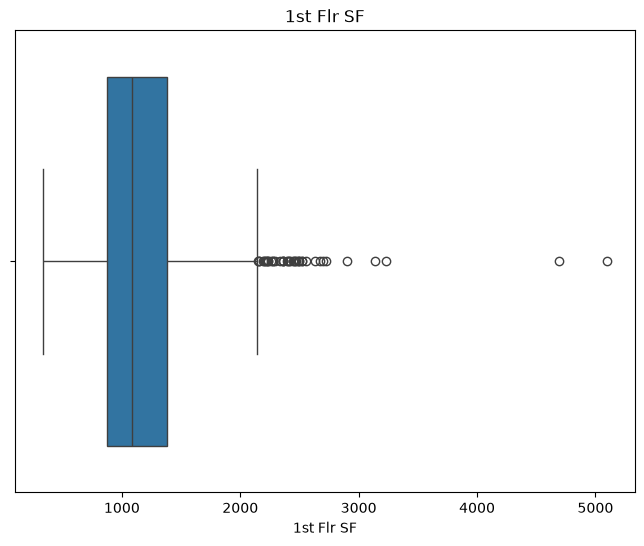

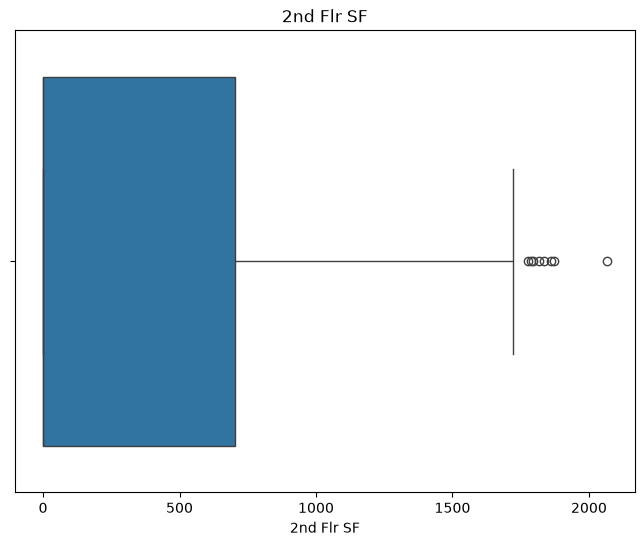

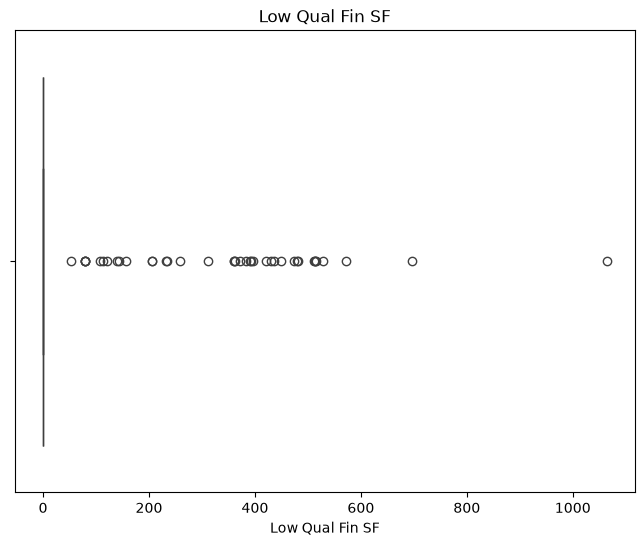

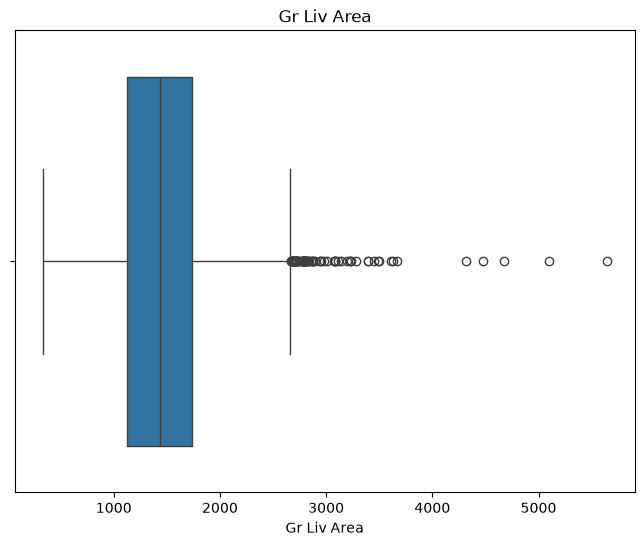

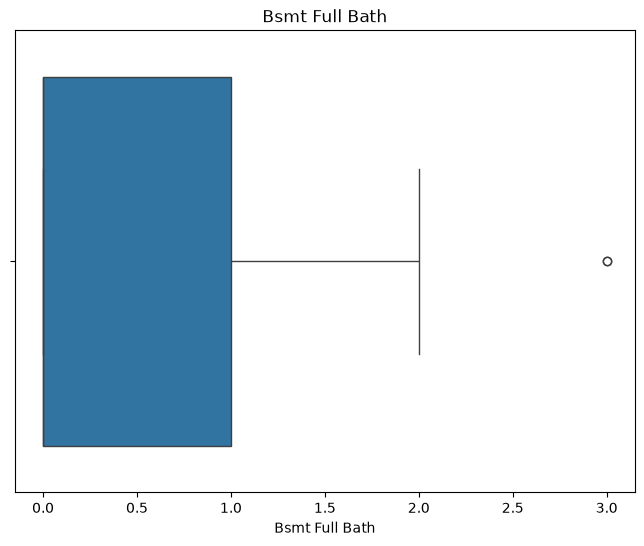

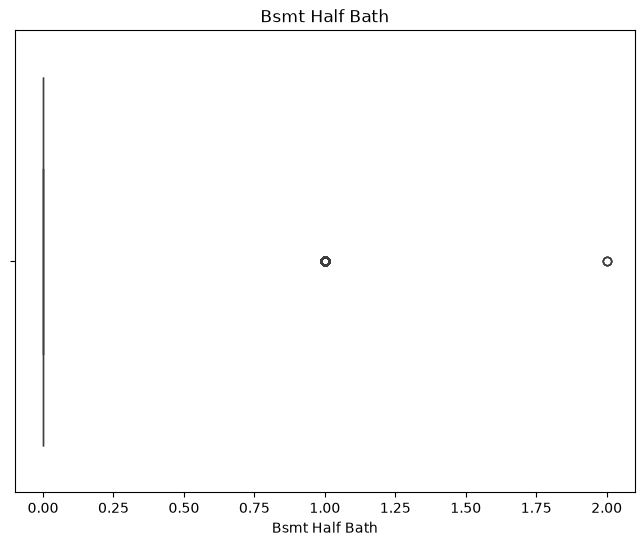

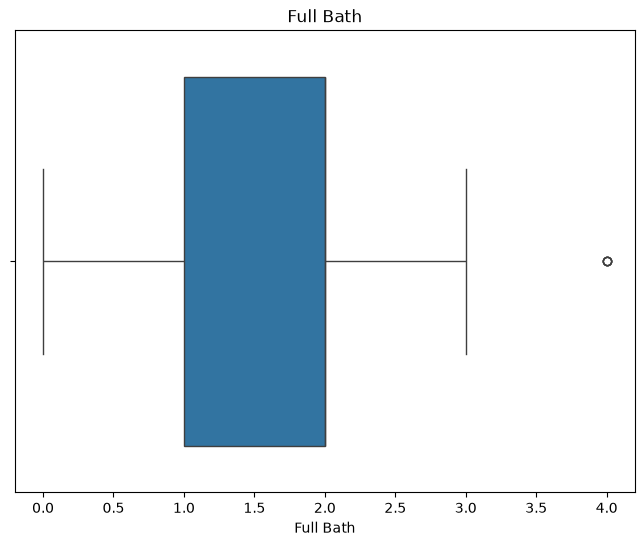

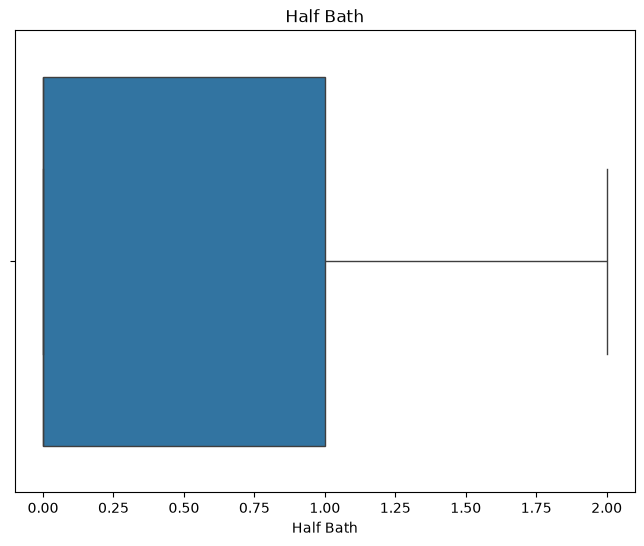

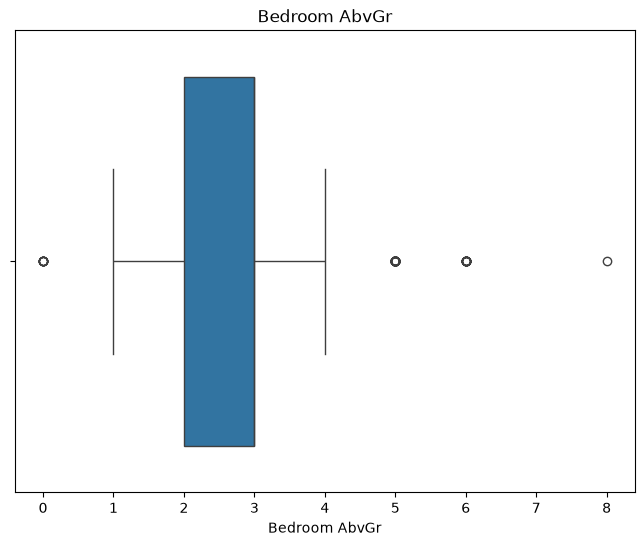

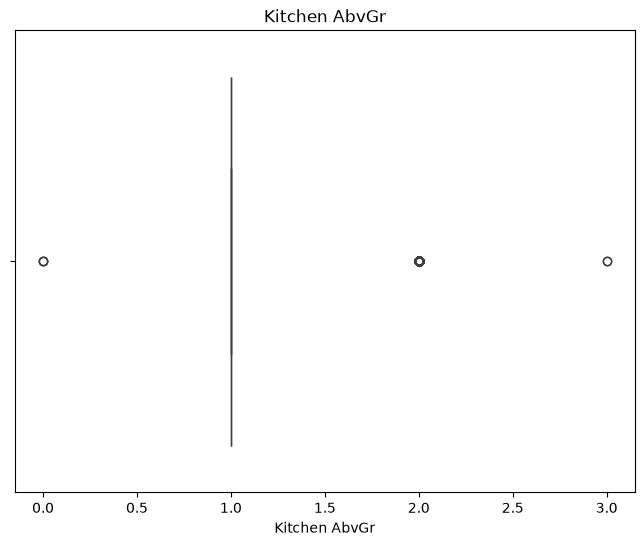

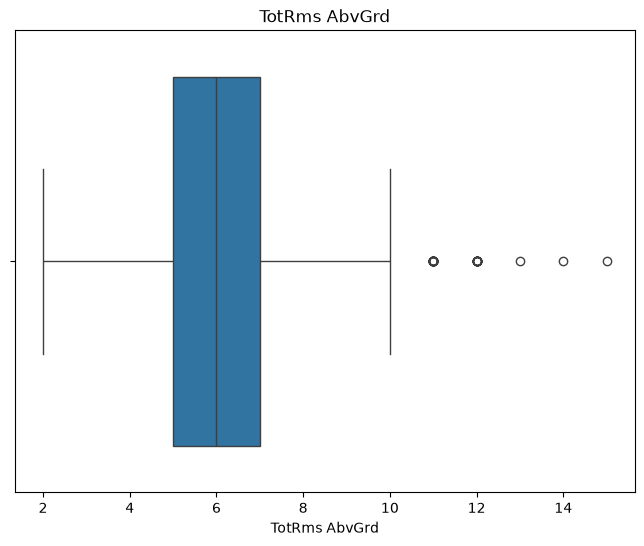

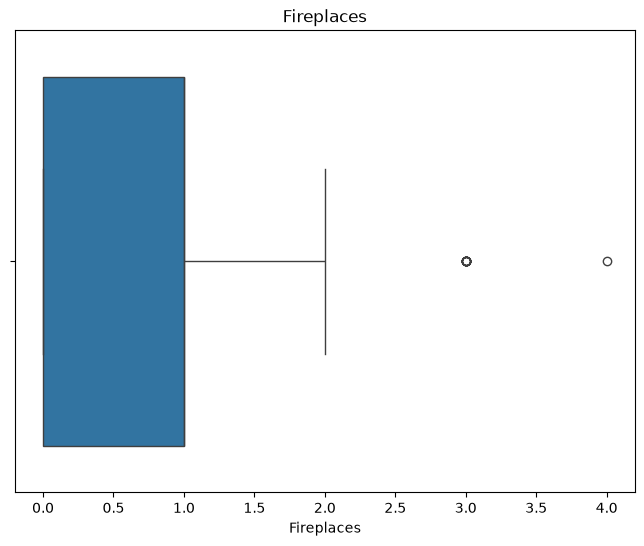

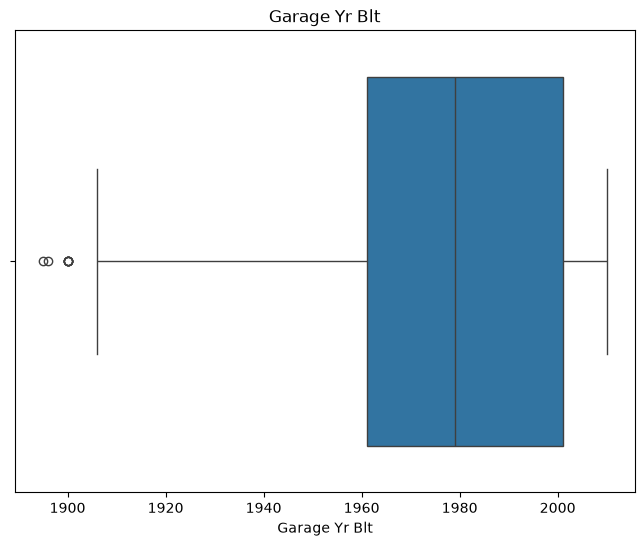

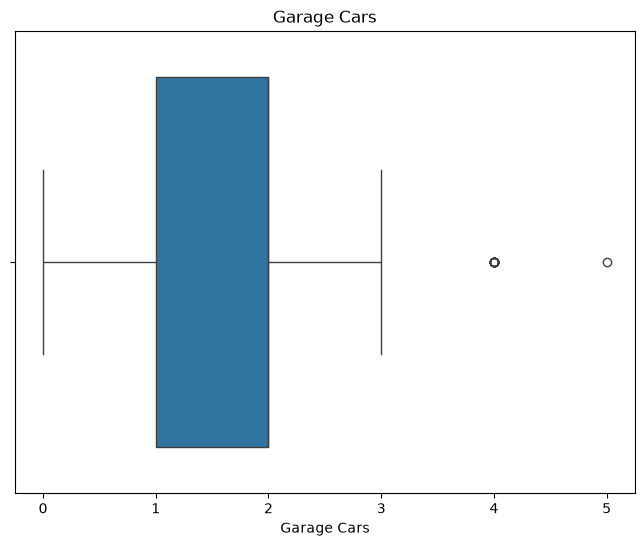

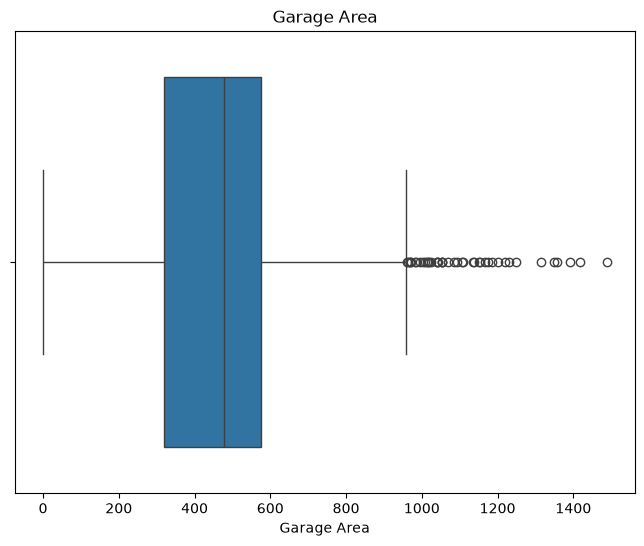

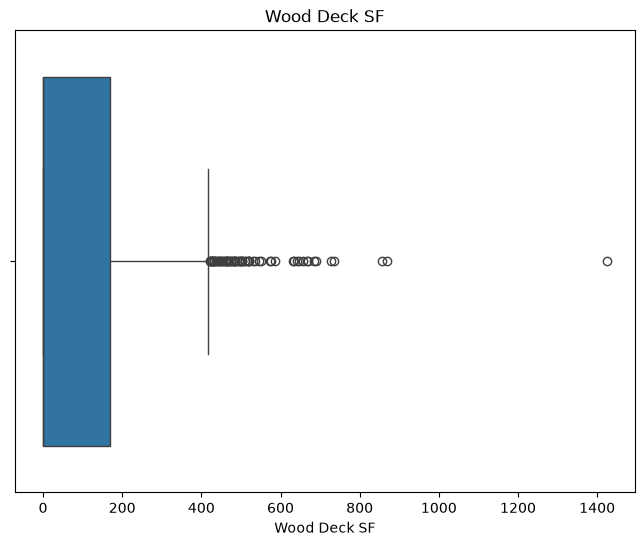

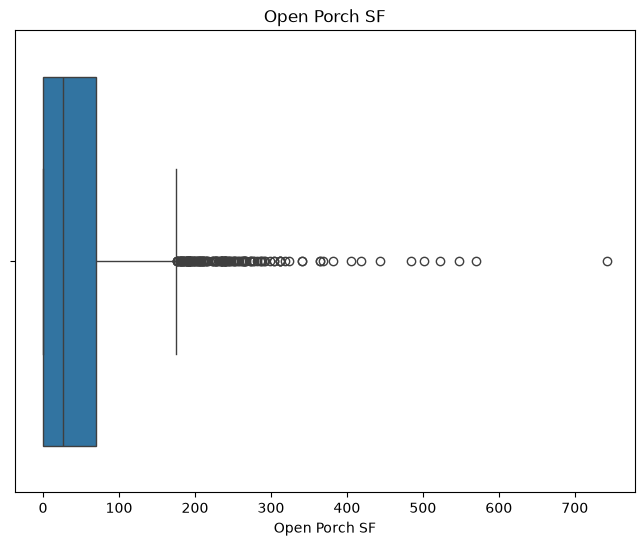

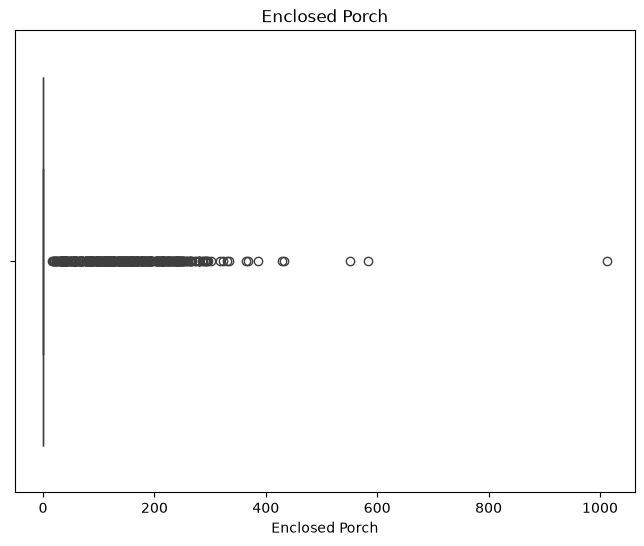

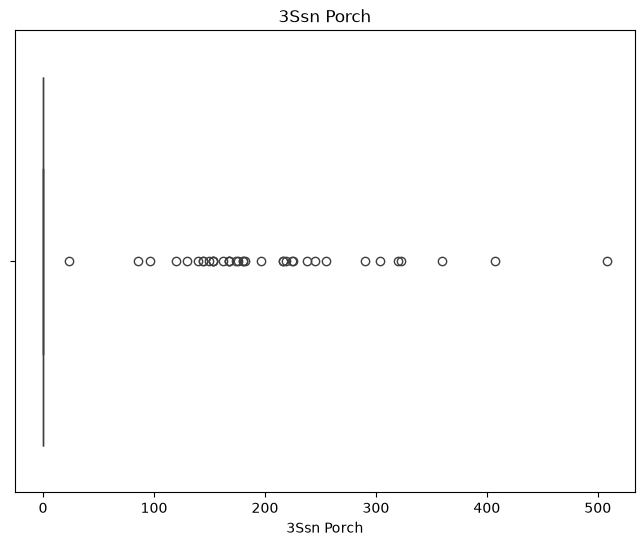

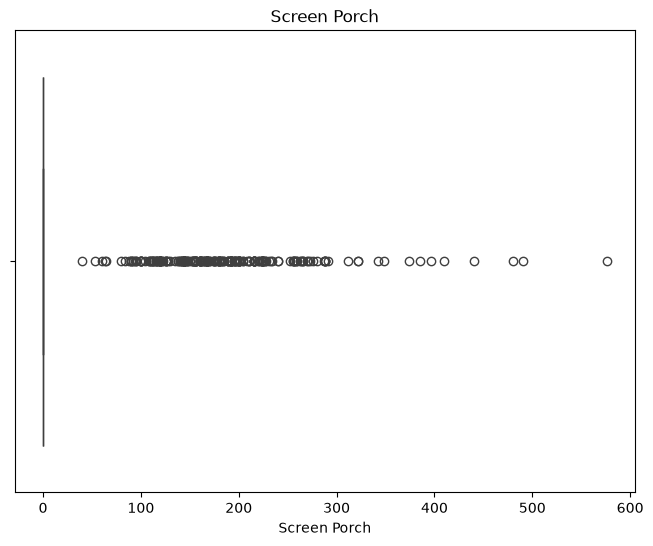

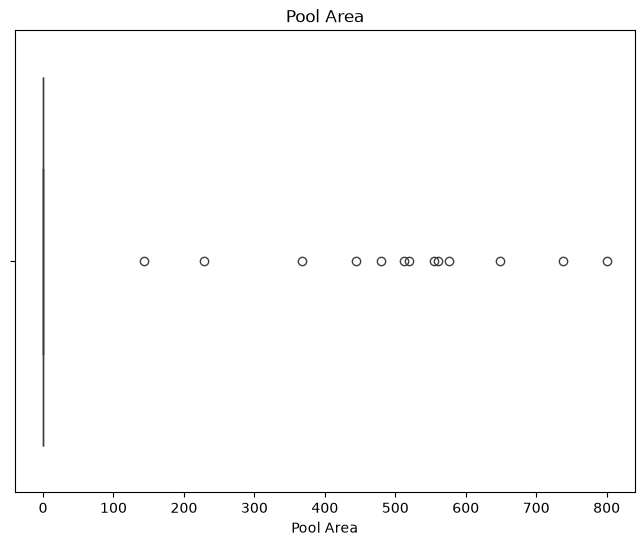

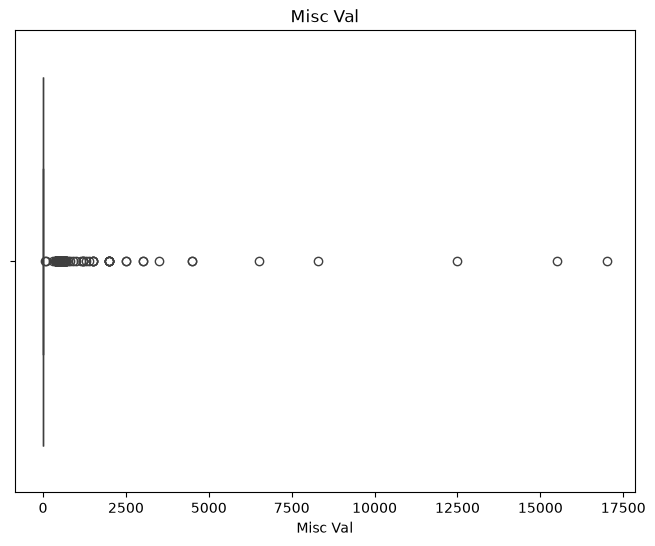

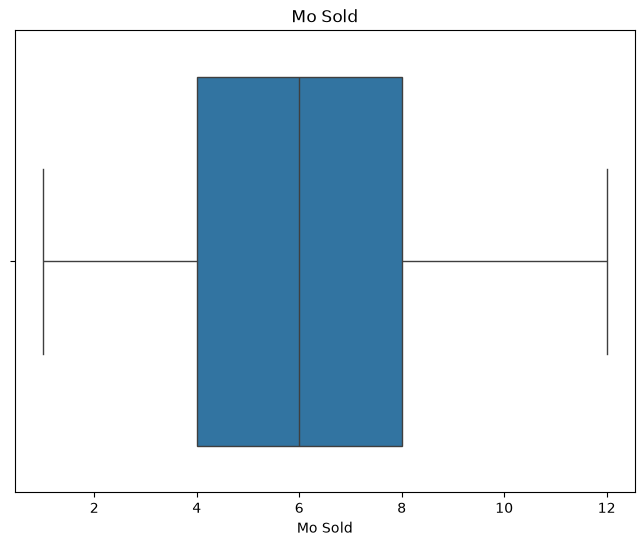

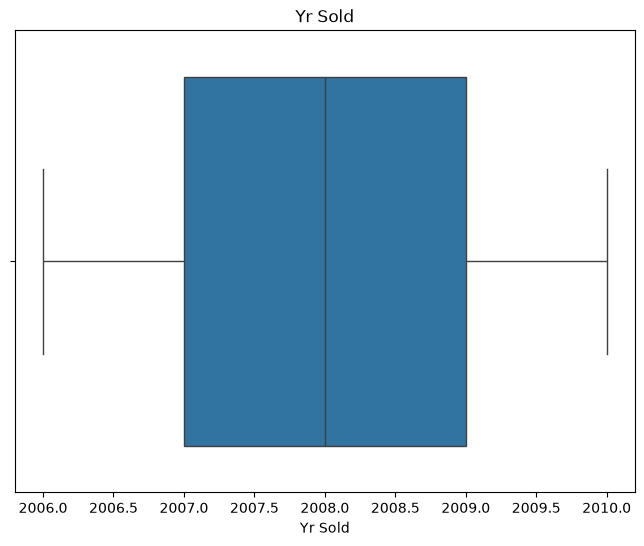

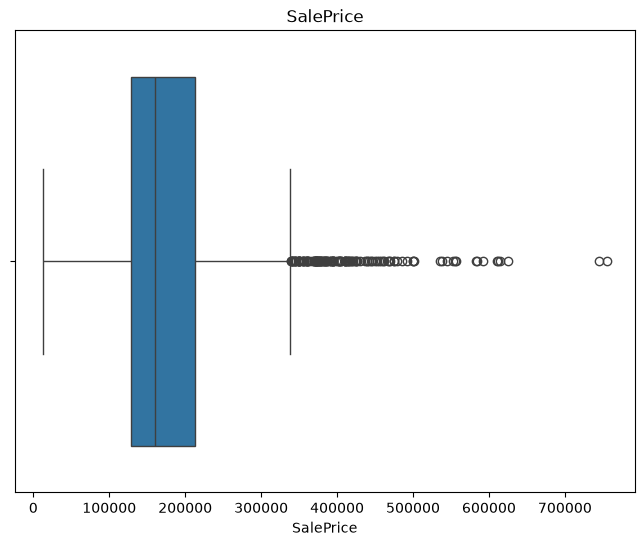

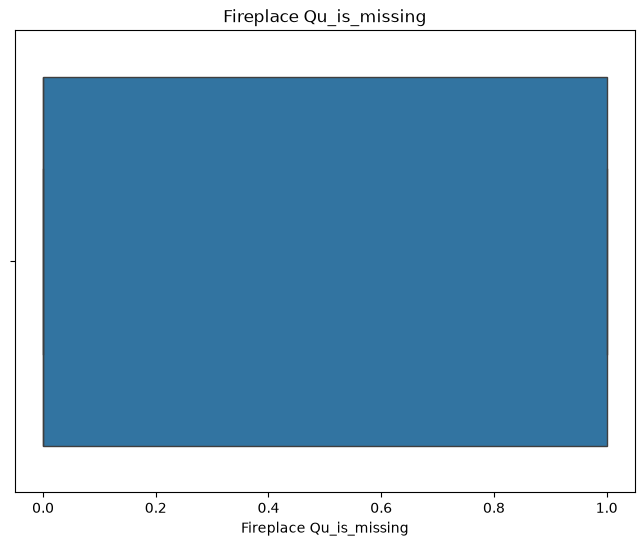

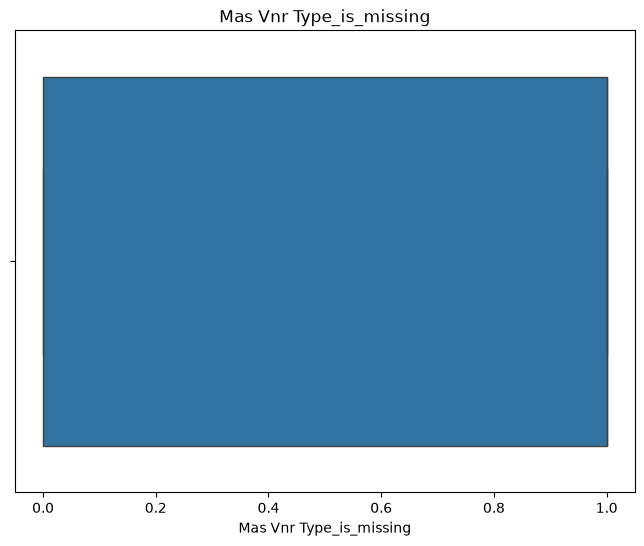

In [188]:
for col in numerical_columns:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=dfcopy[col])
    plt.title(col)
    plt.show()

### Using the IQR method to handle the outliers as the data is skewed and abnormally distributed
yr sold 
mo sold 
half bath 
year remod

In [189]:
outlier_column = numerical_columns.drop(["Year Remod/Add", "Half Bath", "Mo Sold", "Yr Sold", 
                                         "Fireplace Qu_is_missing", "Mas Vnr Type_is_missing"])

print(outlier_column)

Index(['MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Mas Vnr Area', 'BsmtFin SF 1',
       'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Bedroom AbvGr', 'Kitchen AbvGr',
       'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars',
       'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch',
       '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'SalePrice'],
      dtype='str')


In [190]:
iqr_counts = {}

for col in outlier_column:
    s = dfcopy[col]
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    iqr_counts[col] = int(((dfcopy[col] < lower) | (dfcopy[col] > upper)).sum())

pd.DataFrame({ "IQR_outliers": iqr_counts })

,IQR_outliers
MS SubClass,208
Lot Frontage,257
Lot Area,126
Overall Qual,4
Overall Cond,251
Year Built,9
Mas Vnr Area,200
BsmtFin SF 1,15
BsmtFin SF 2,350
Bsmt Unf SF,56


### Trimming the below outliers in the columns because the count of outliers is too low
- Overall Qual
- Year Built
- BsmtFin SF 1
- 2nd Flr SF
- Bsmt Full Bath
- Full Bath
- Fireplaces
- Garage Yr Blt
- Garage Cars
- Pool Area

In [191]:
trim_col = ["Overall Qual", "Year Built", "BsmtFin SF 1", "2nd Flr SF", "Bsmt Full Bath", 
            "Full Bath", "Fireplaces", "Garage Yr Blt", "Garage Cars", "Pool Area"]

Q1 = dfcopy[trim_col].quantile(0.25)
Q3 = dfcopy[trim_col].quantile(0.75)

IQR = Q3 - Q1

lower_limit, upper_limit = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

keep_mask = ((dfcopy[trim_col] >= lower_limit) & (dfcopy[trim_col] <= upper_limit)).all(axis=1)

dfcopy = dfcopy[keep_mask]

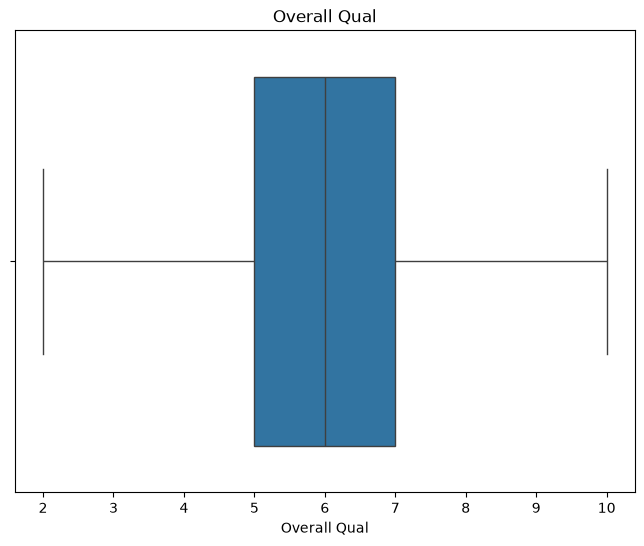

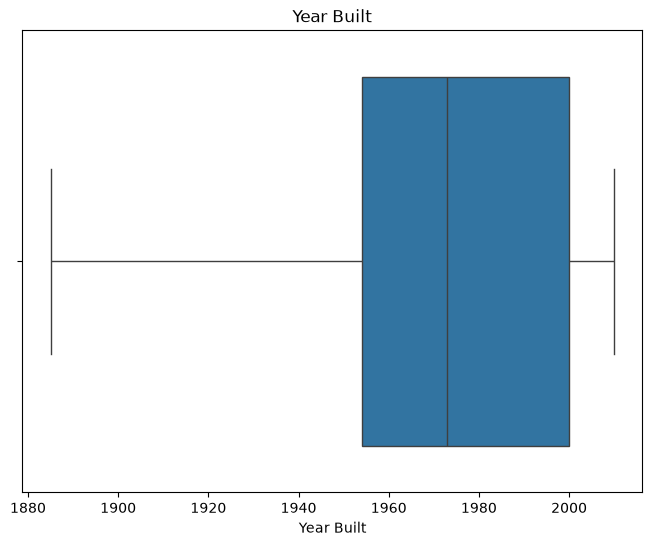

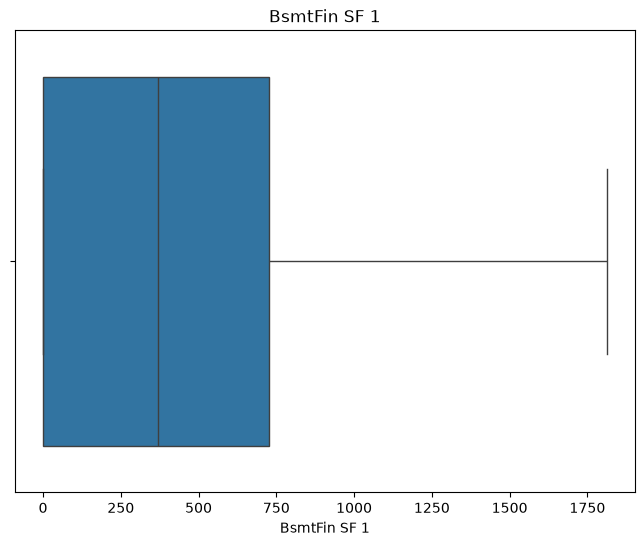

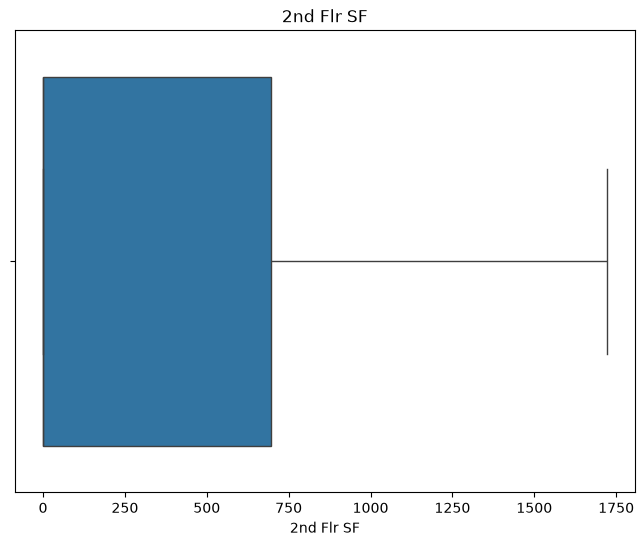

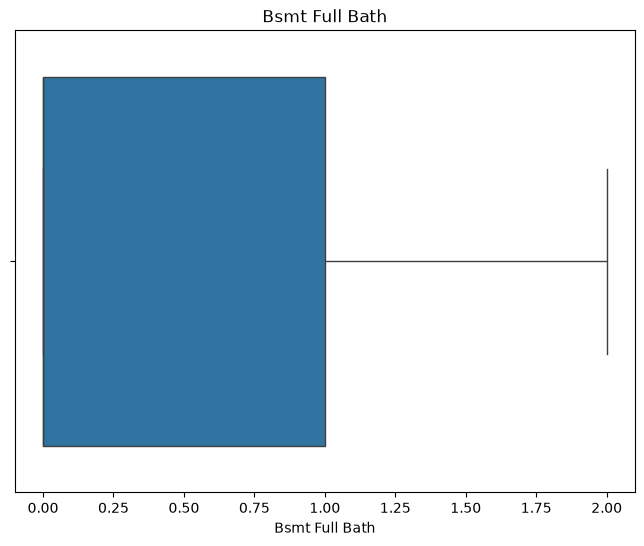

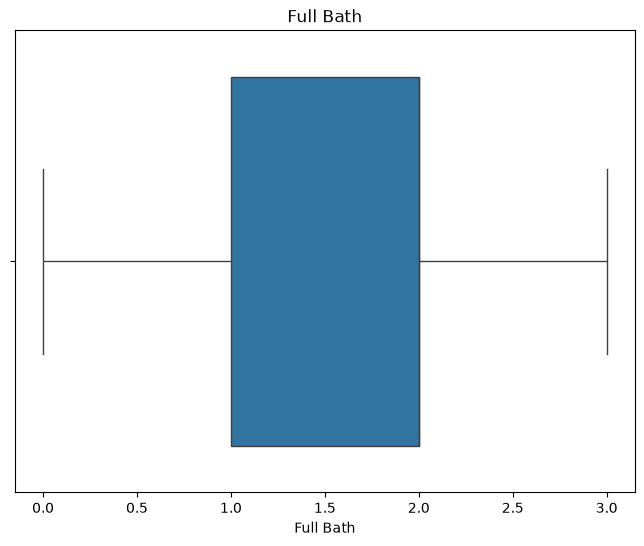

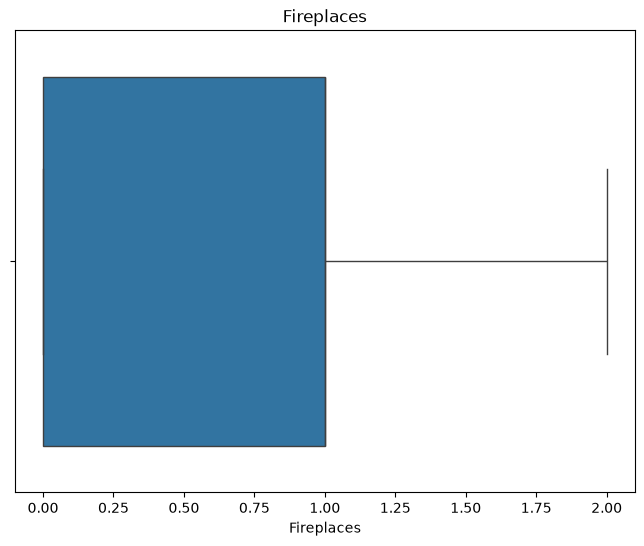

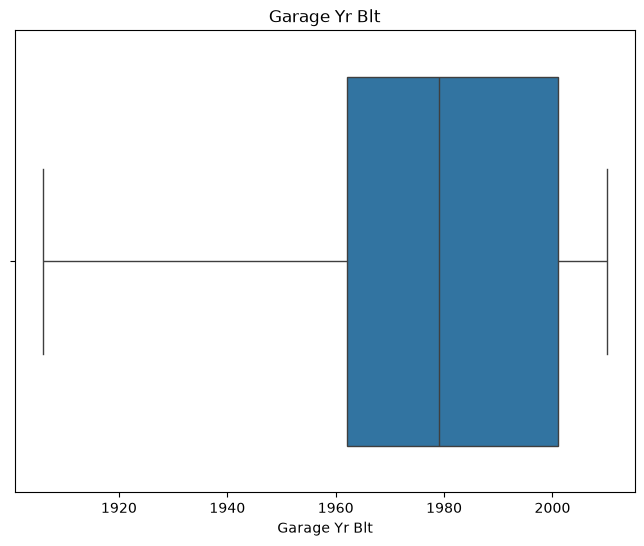

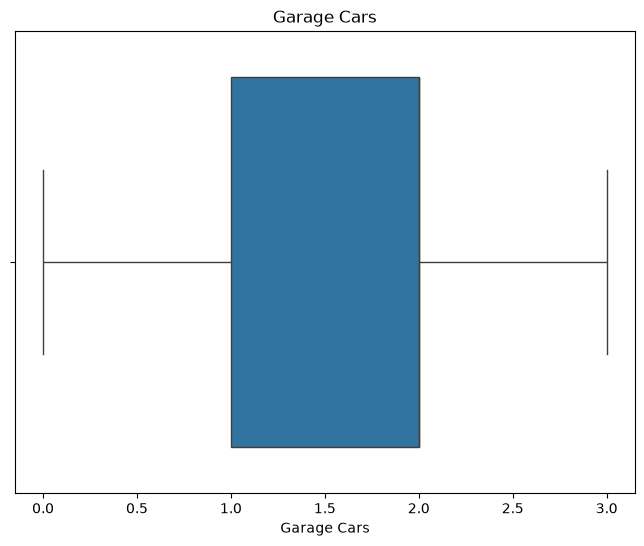

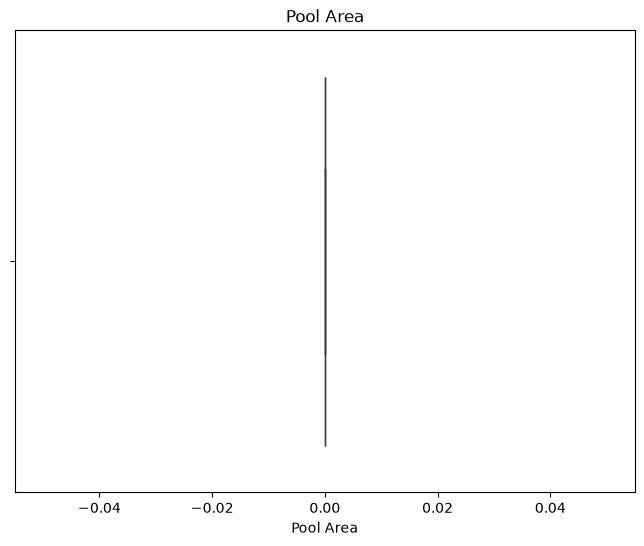

In [192]:
for col in trim_col:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=dfcopy[col])
    plt.title(col)
    plt.show()

### Capping the following columns outliers as the outlier count is too high
- MS SubClass
- Lot Frontage
- Lot Area
- Overall Cond
- Mas Vnr Area
- BsmtFin SF 2
- Bsmt Unf SF
- Total Bsmt SF
- 1st Flr SF
- Low Qual Fin SF
- Gr Liv Area
- Bsmt Half Bath
- Bedroom AbvGr
- Kitchen AbvGr
- TotRms AbvGrd
- Garage Area
- Wood Deck SF
- Open Porch SF
- Enclosed Porch
- 3Ssn Porch
- Screen Porch
- Misc Val
- SalePrice

In [193]:
capped_col = ["SalePrice", "Misc Val", "Screen Porch", "3Ssn Porch", "Enclosed Porch", 
              "Open Porch SF", "Wood Deck SF", "Garage Area", "TotRms AbvGrd", "Kitchen AbvGr", 
              "Bedroom AbvGr", "Bsmt Half Bath", "Gr Liv Area", "Low Qual Fin SF", "1st Flr SF", 
              "Total Bsmt SF", "Bsmt Unf SF", "BsmtFin SF 2", "Mas Vnr Area", "Overall Cond", 
              "Lot Area", "Lot Frontage", "MS SubClass"]

for col in capped_col: 
    Q1, Q3 = dfcopy[col].quantile(0.25), dfcopy[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit, upper_limit = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    dfcopy[col] = dfcopy[col].clip(lower=lower_limit, upper=upper_limit)


In [194]:
dfcopy.shape

(2823, 80)

## Finding the correlation among the numerical columns based on the sale price target

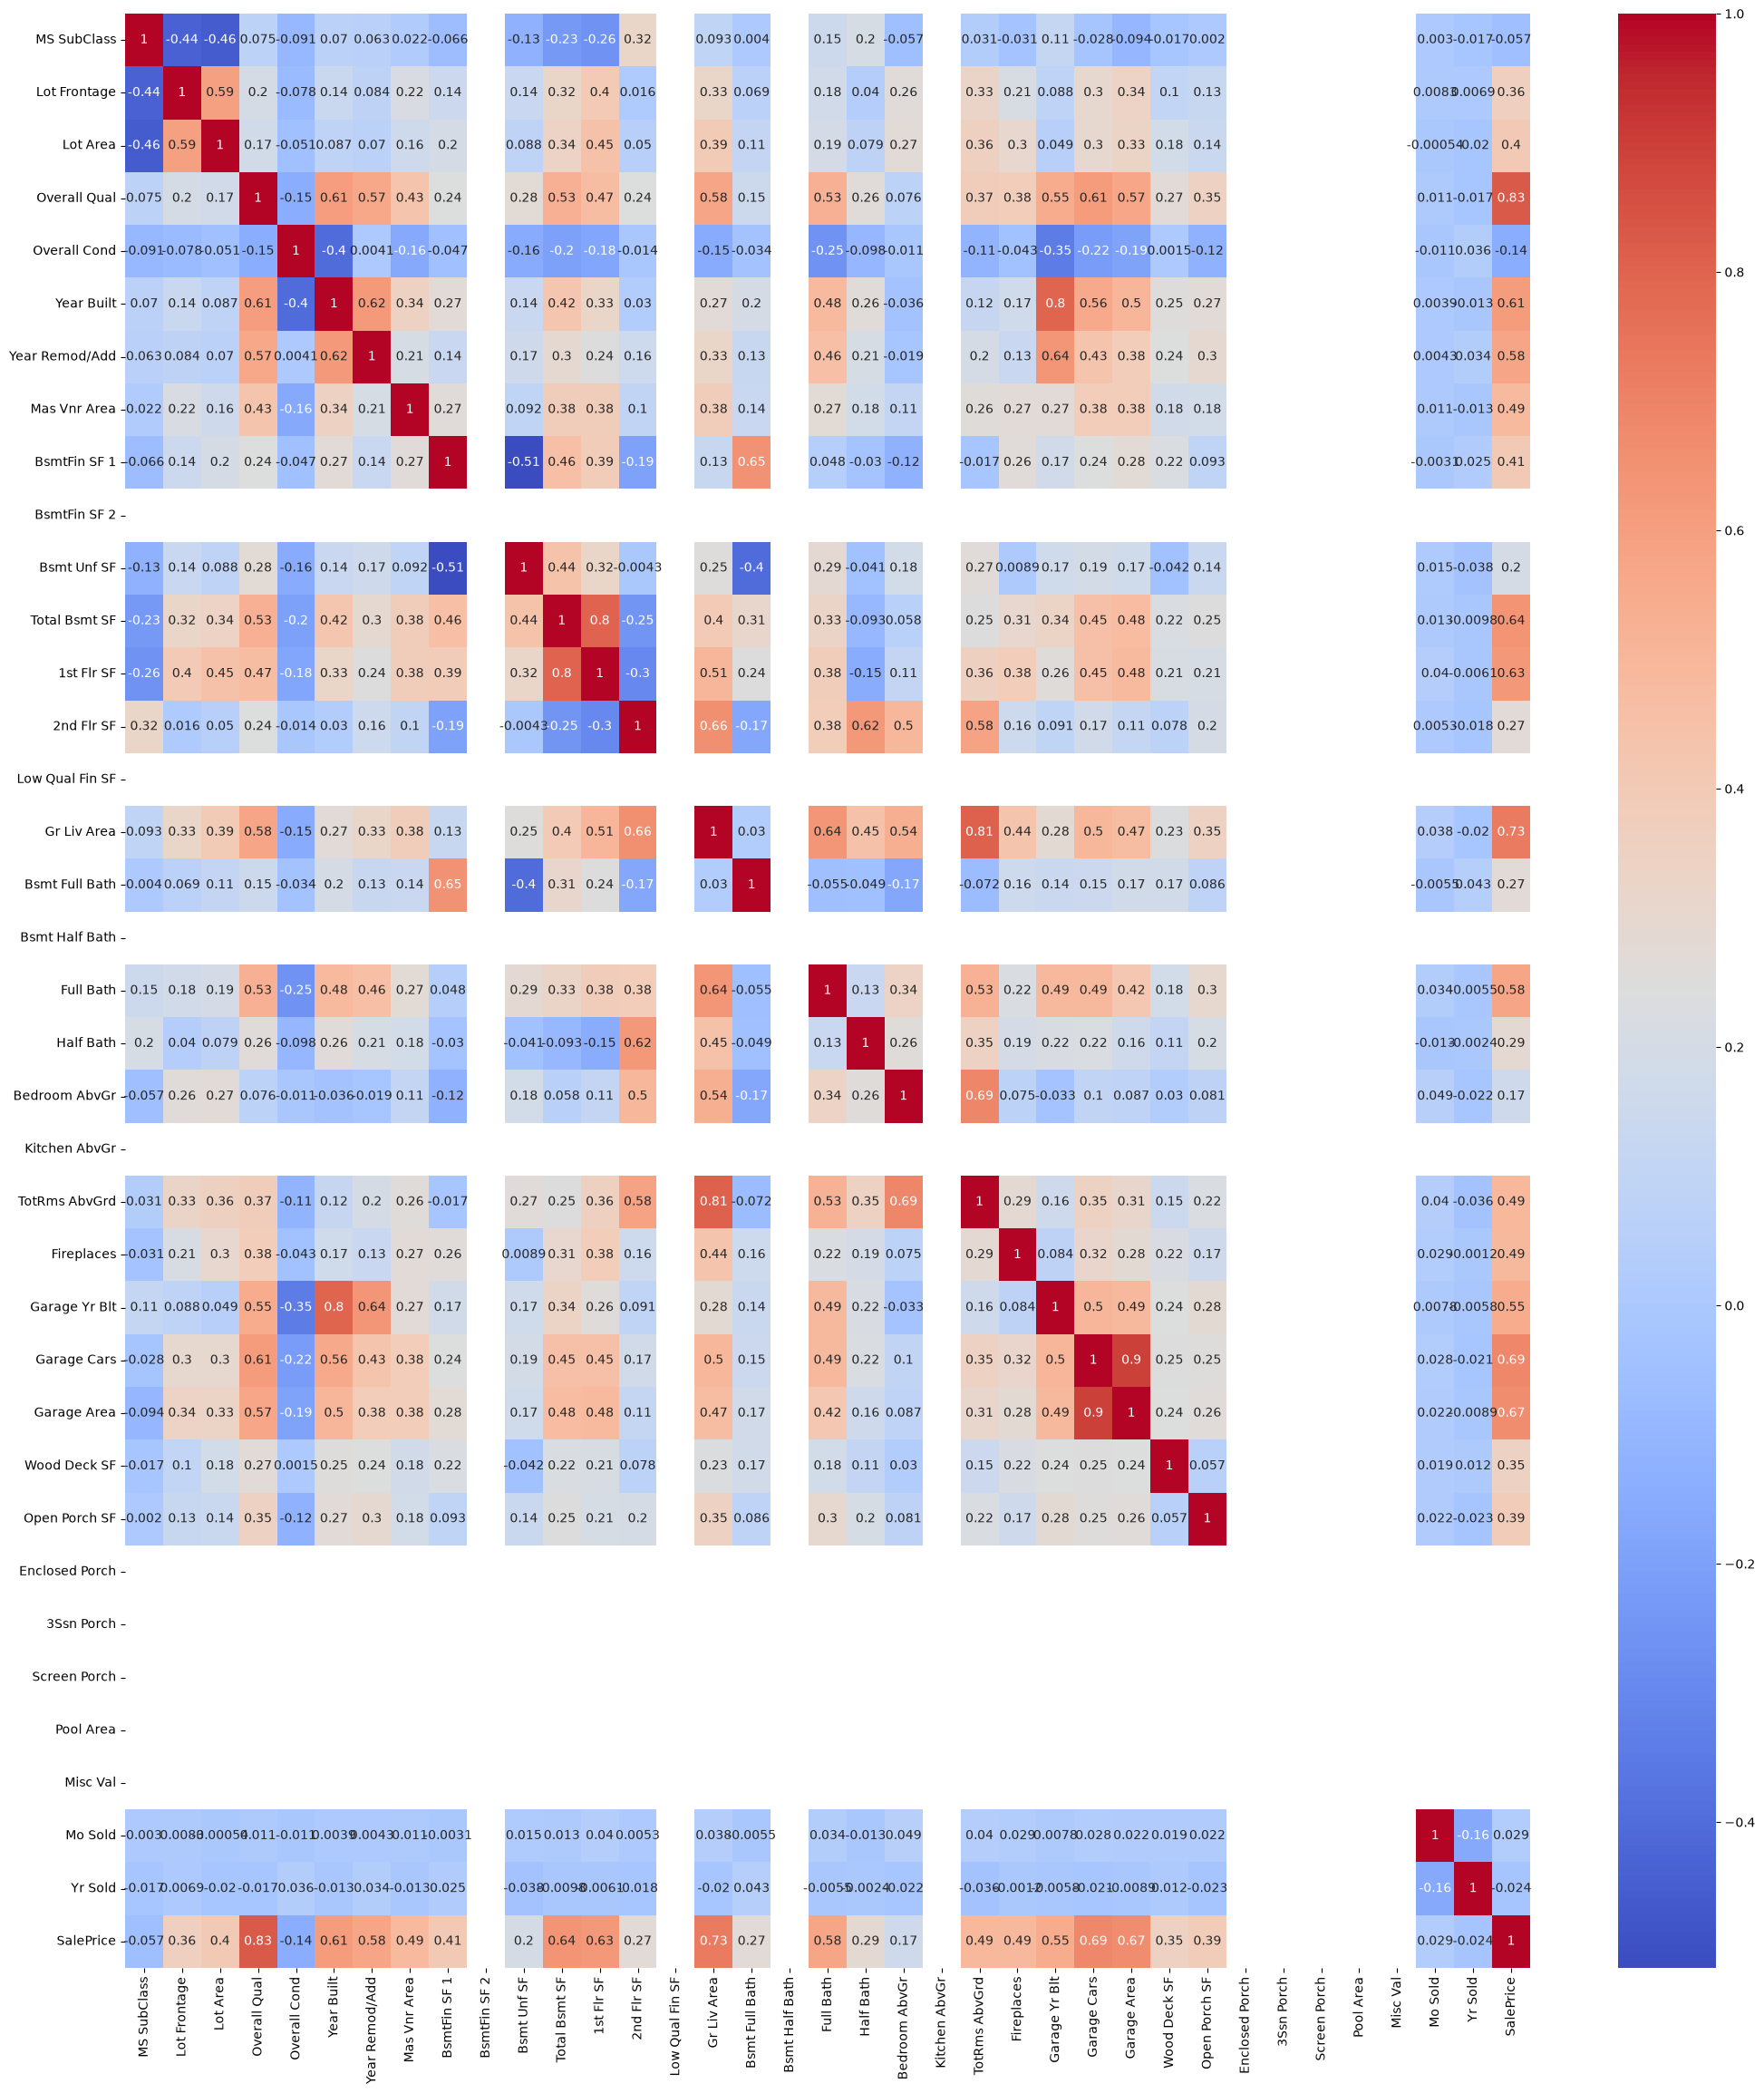

In [195]:
corr_col = numerical_columns.drop(["Fireplace Qu_is_missing", "Mas Vnr Type_is_missing"])

corr = dfcopy[corr_col].corr()

plt.figure(figsize=(25,28))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

The numerical columns having strong relation with sale price are:
- Overall Qual
- Gr Liv Area
- Garage Cars

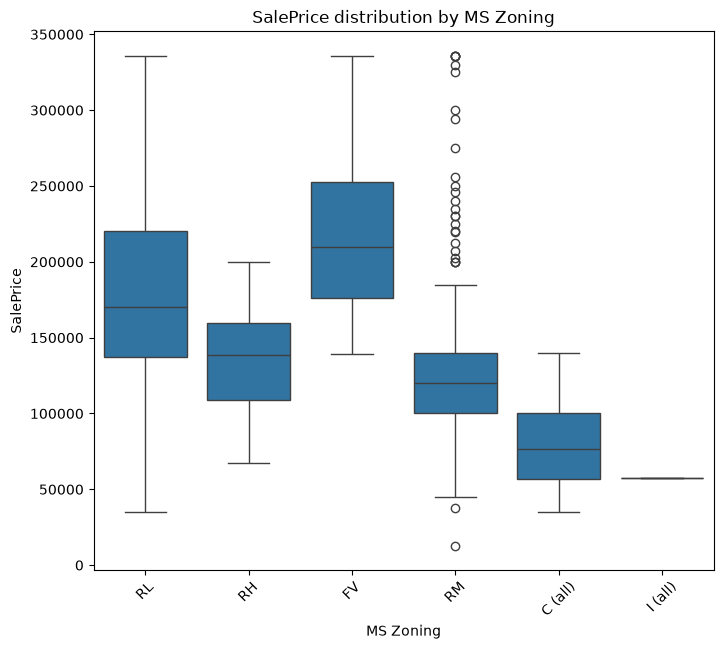

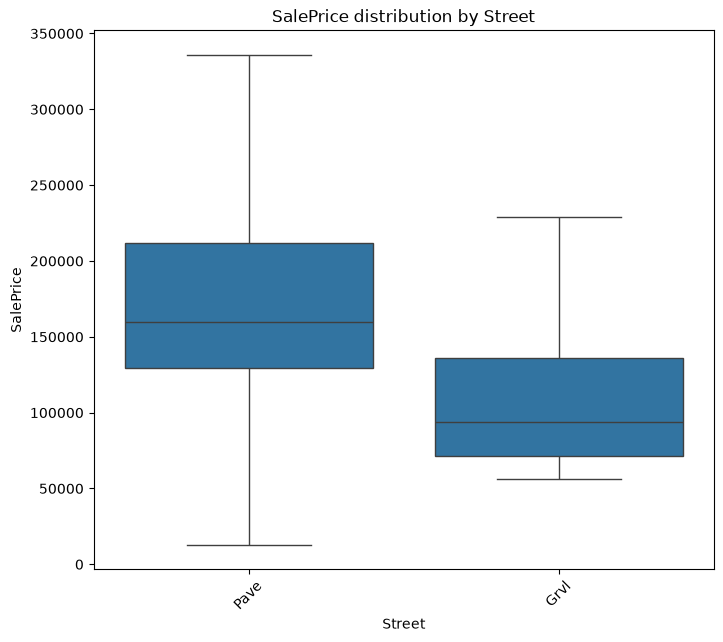

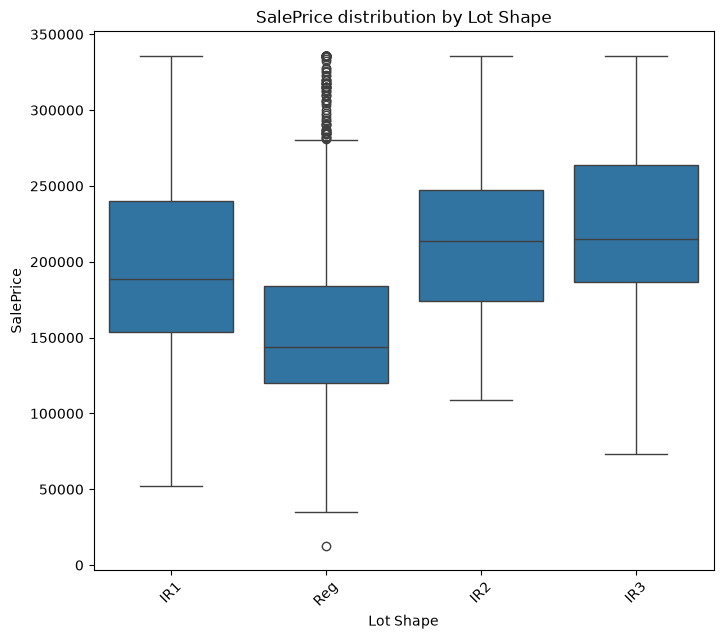

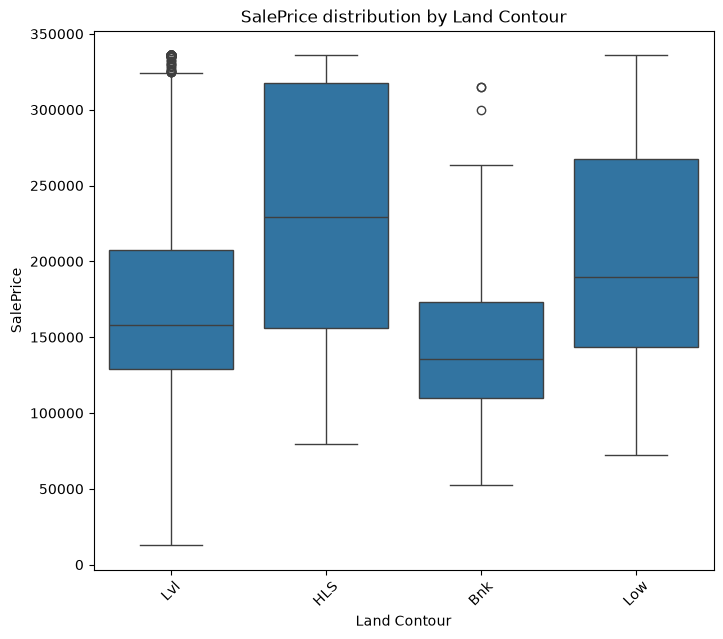

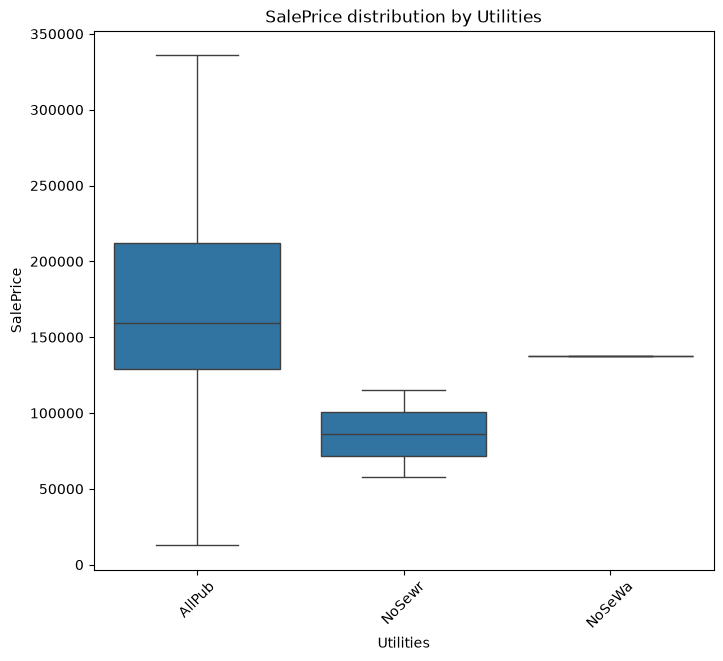

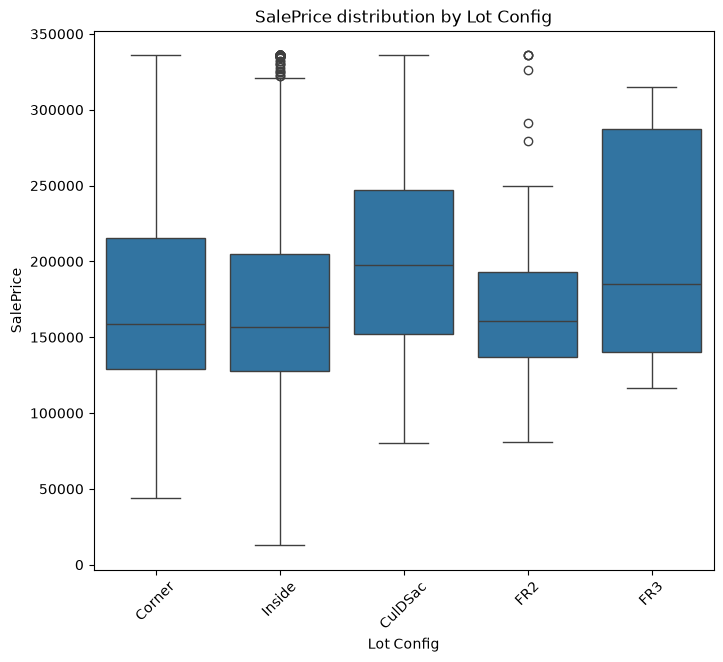

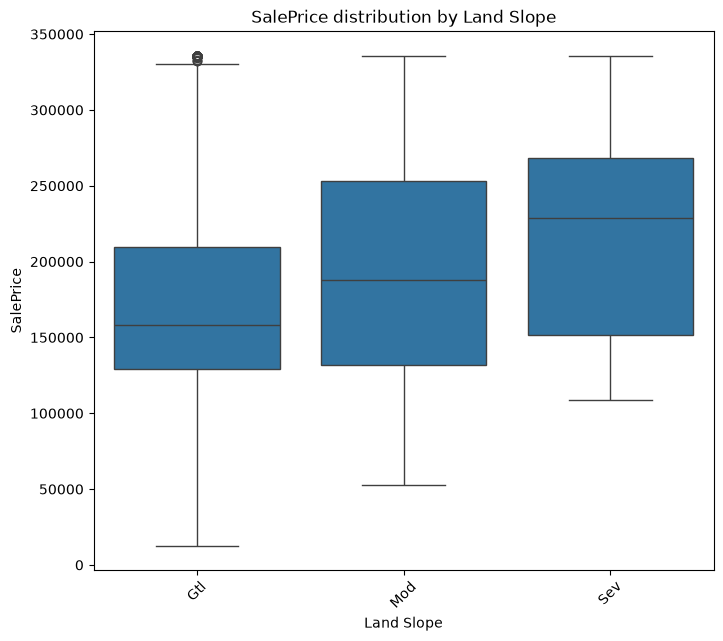

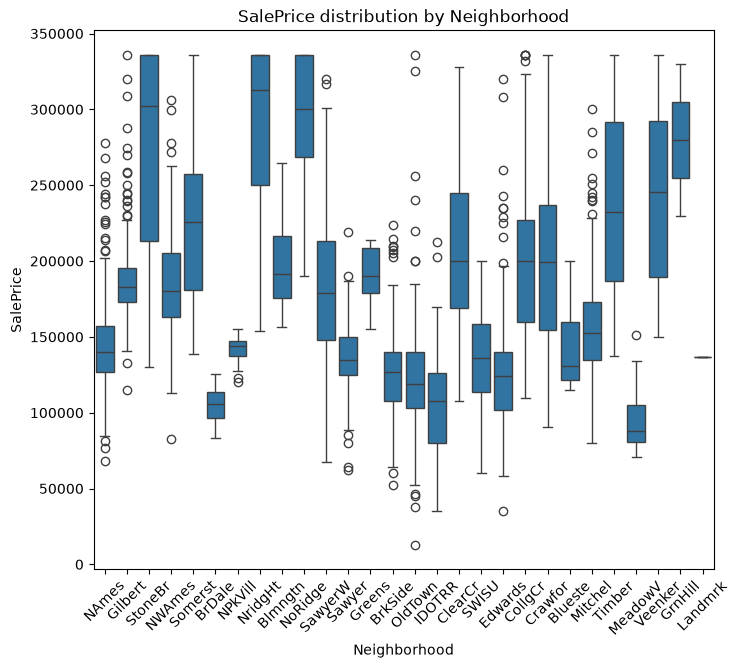

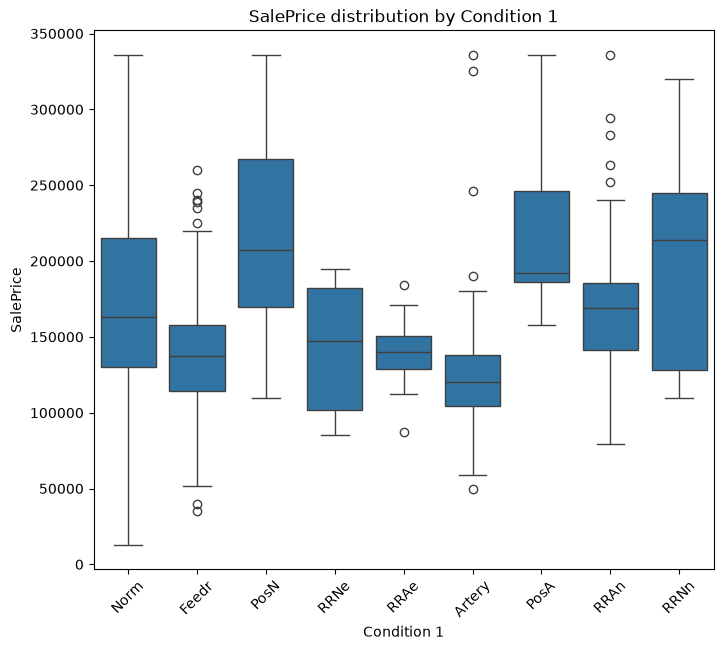

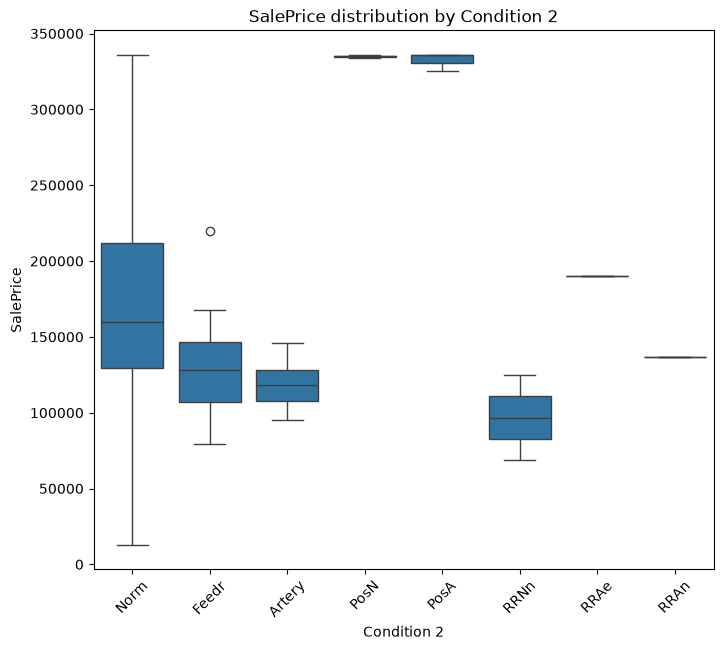

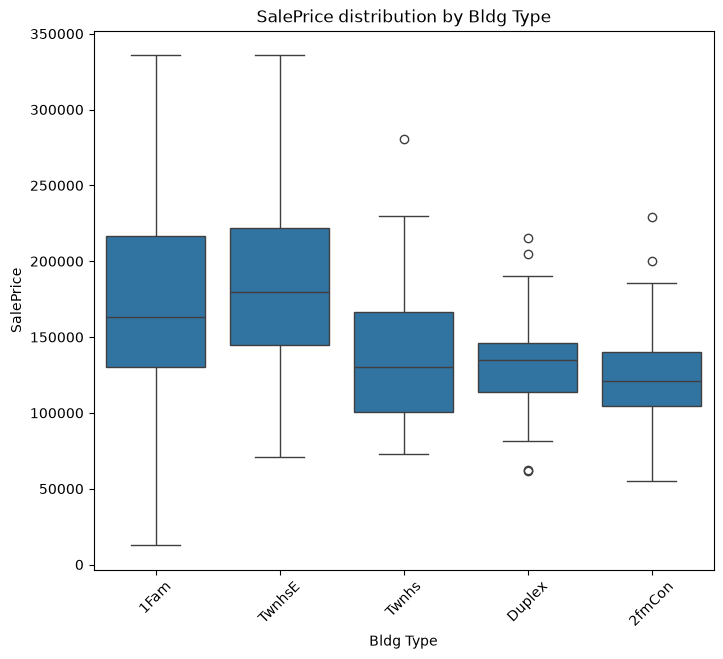

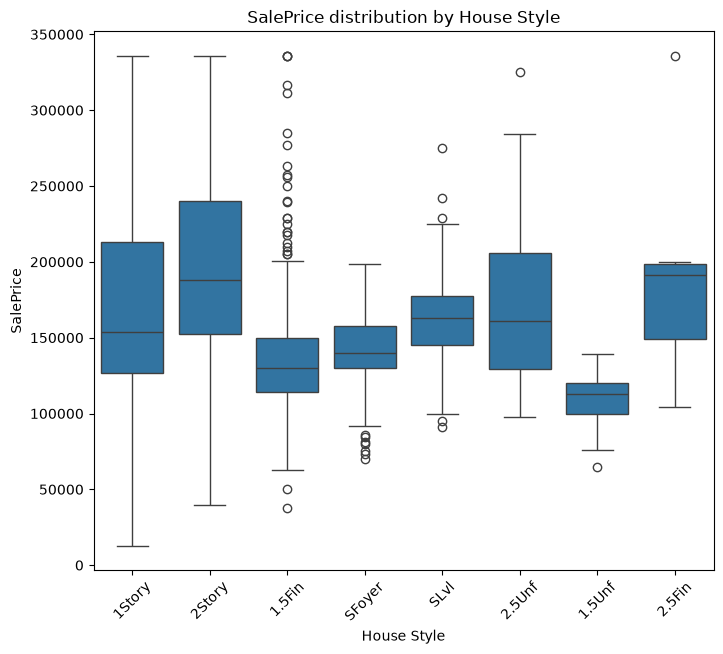

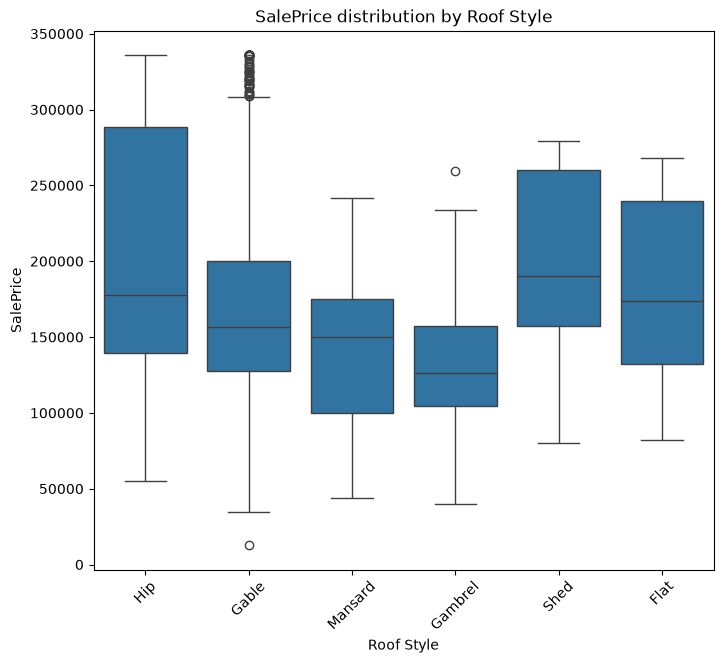

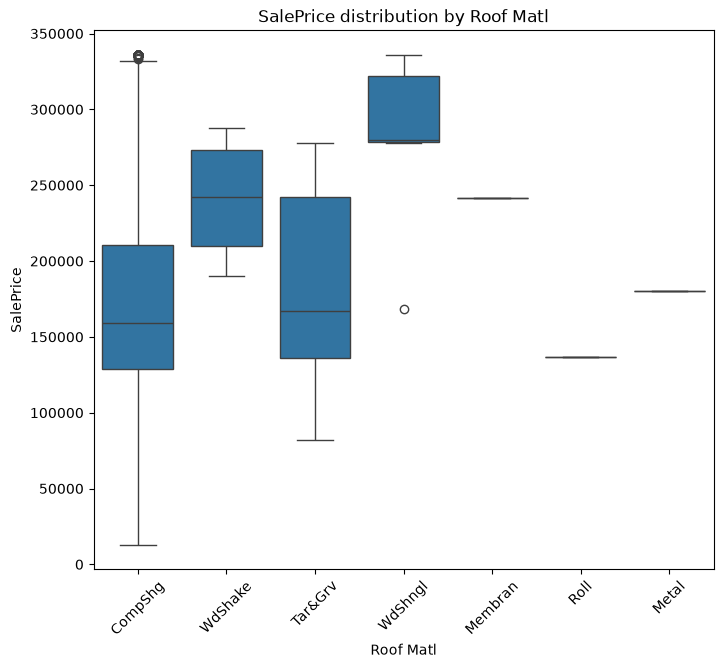

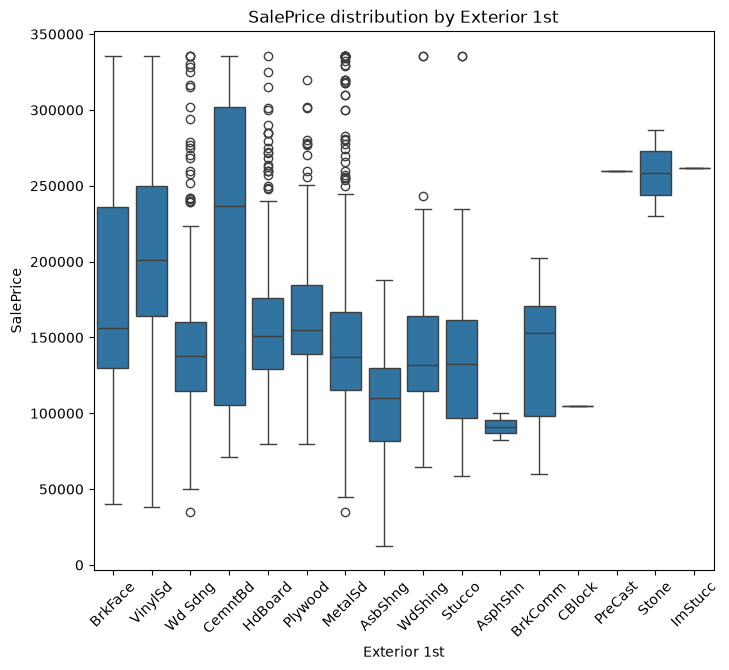

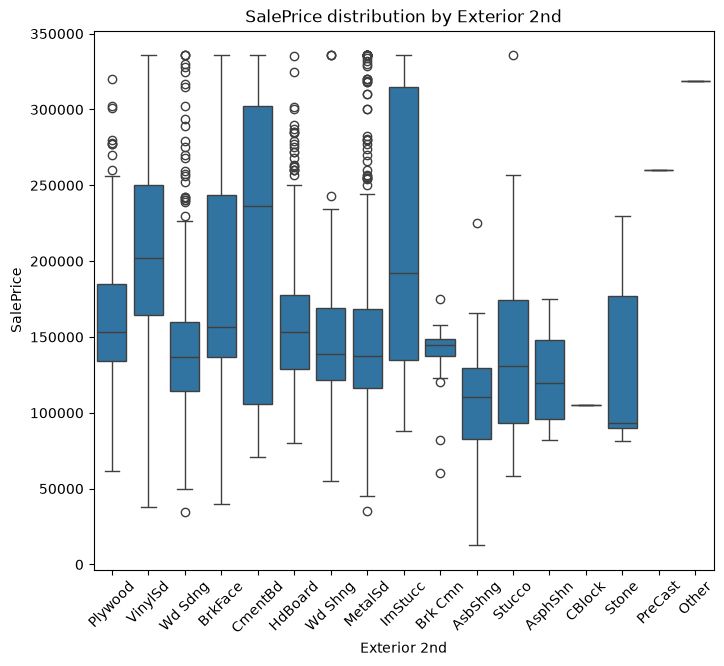

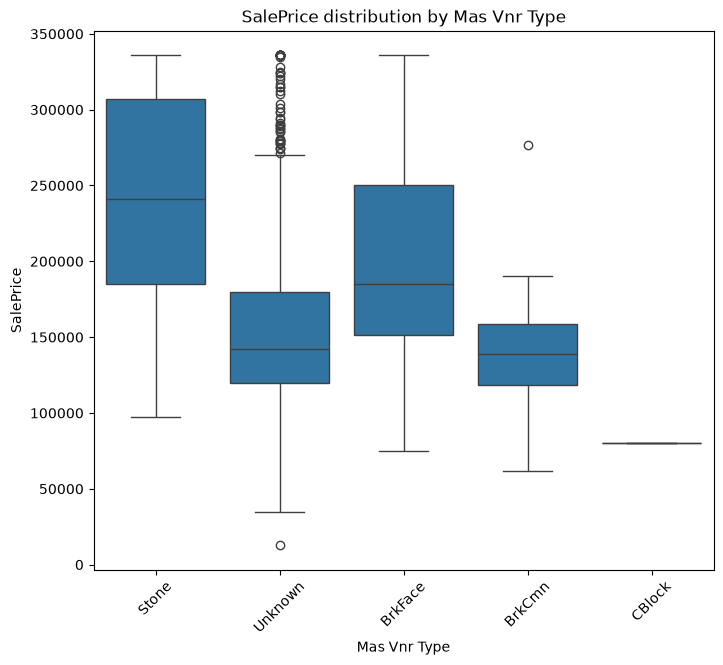

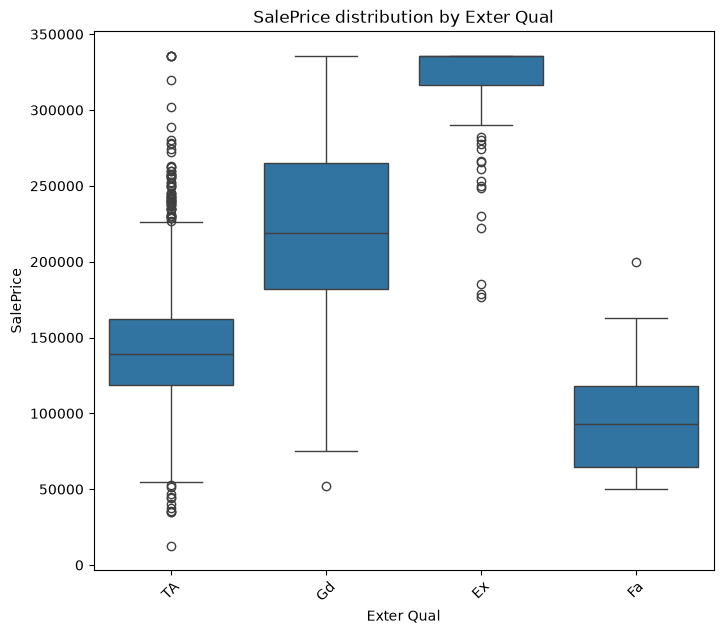

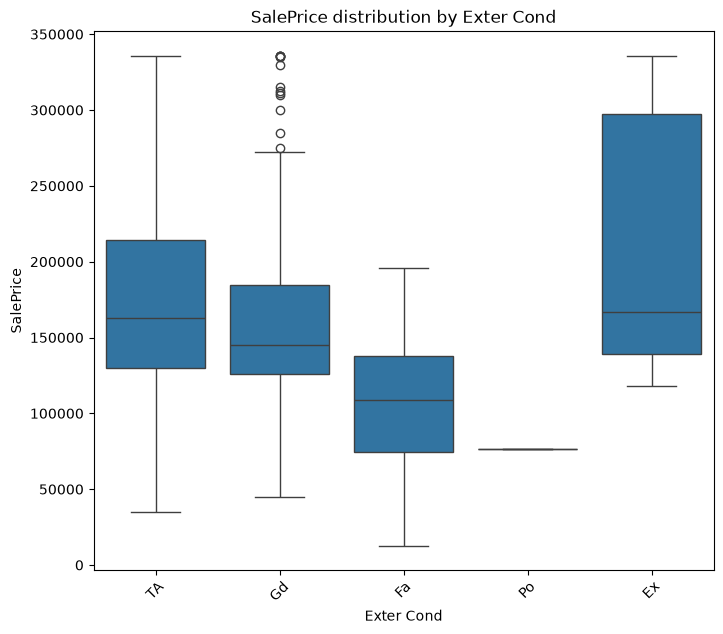

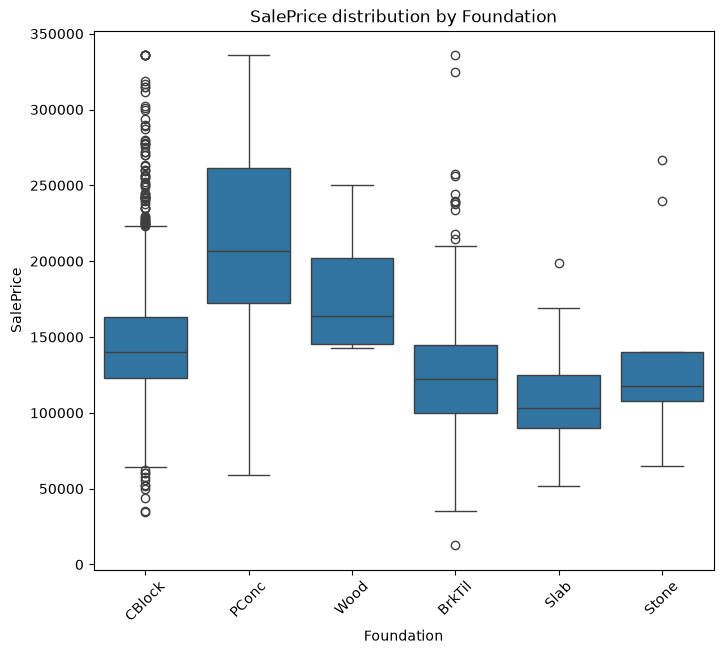

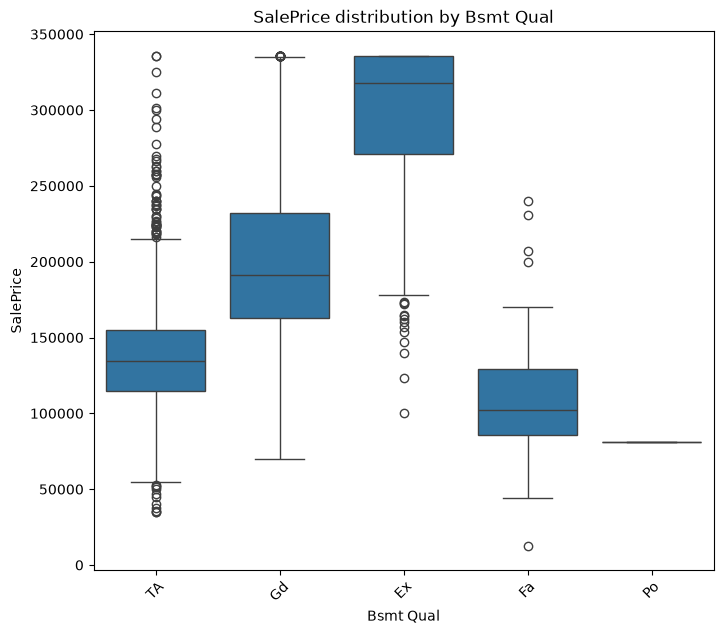

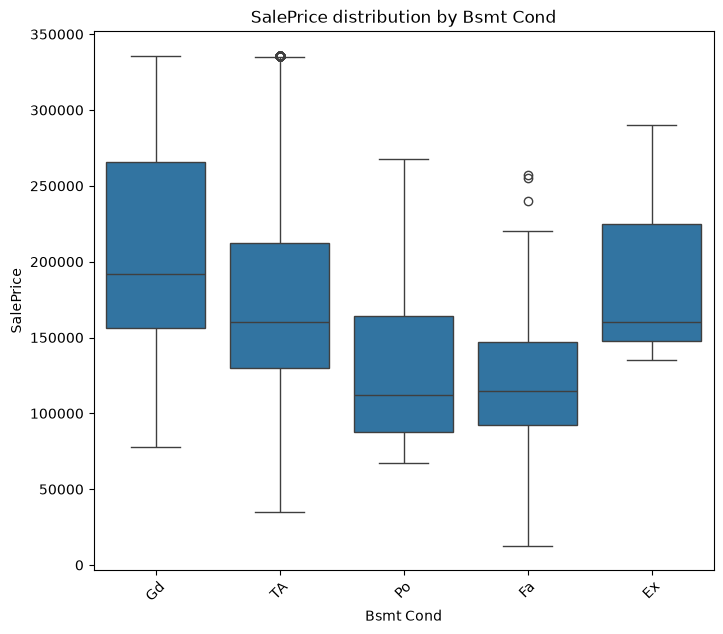

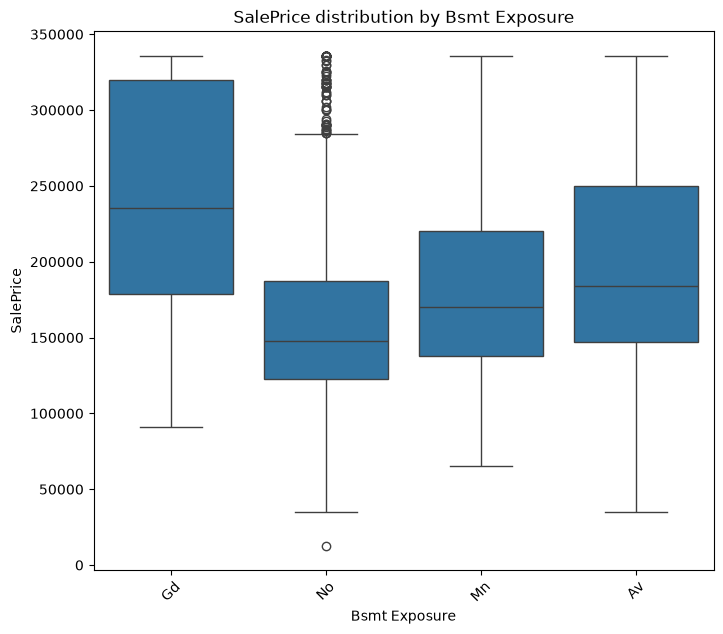

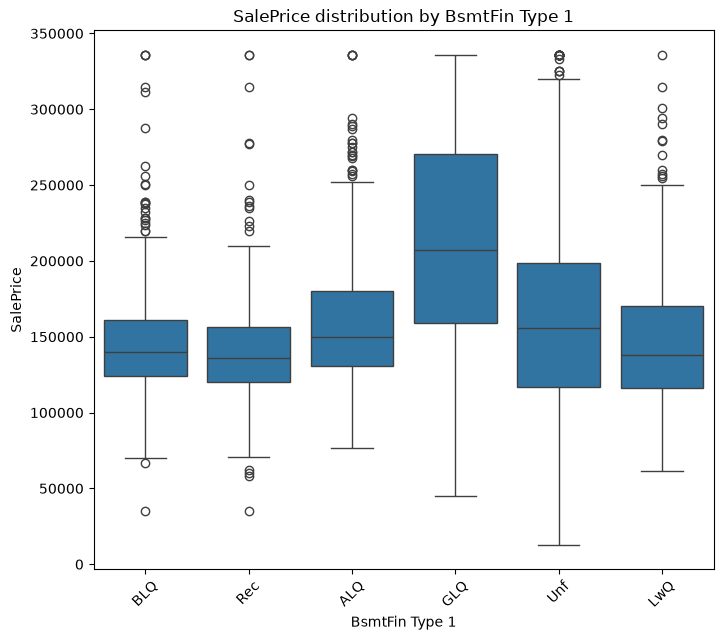

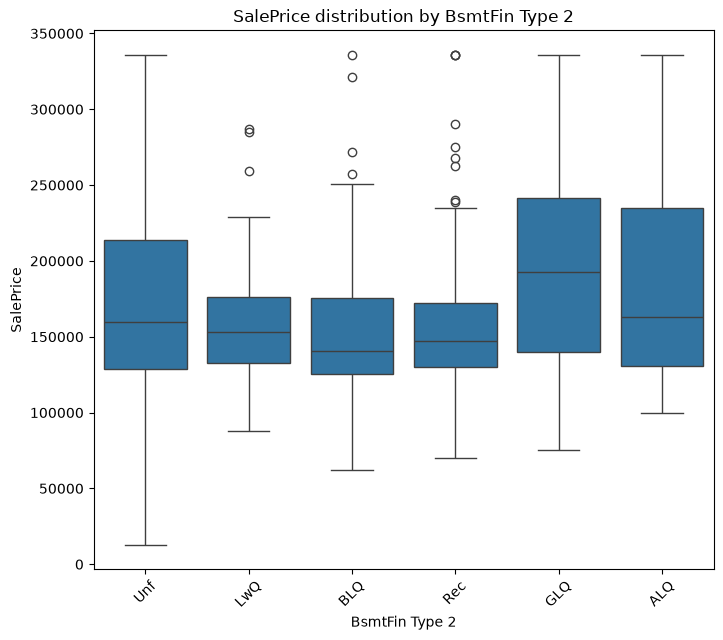

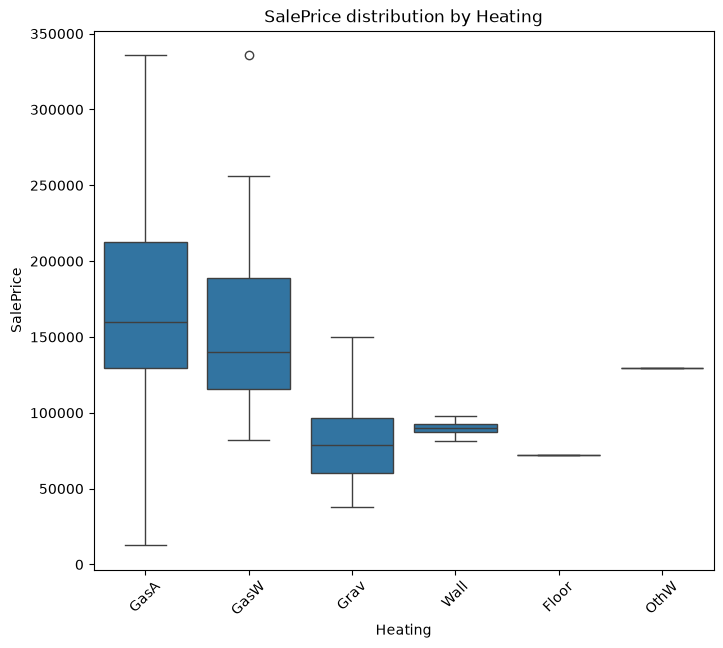

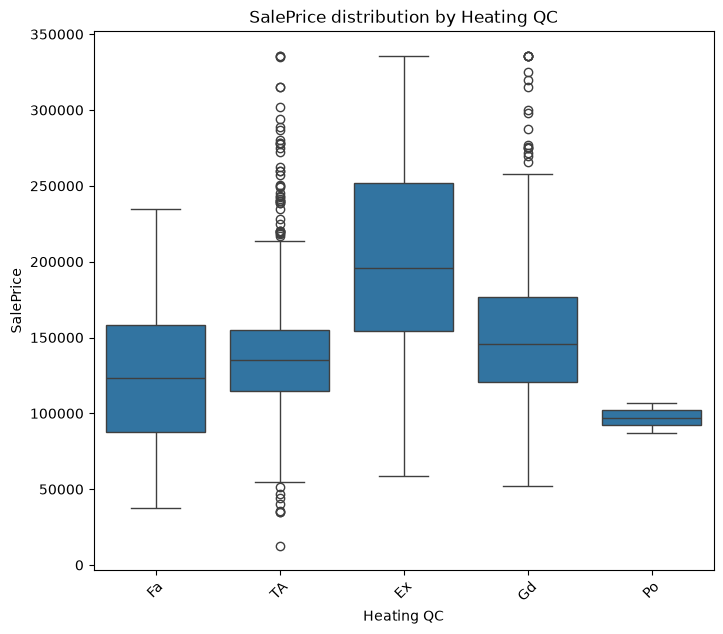

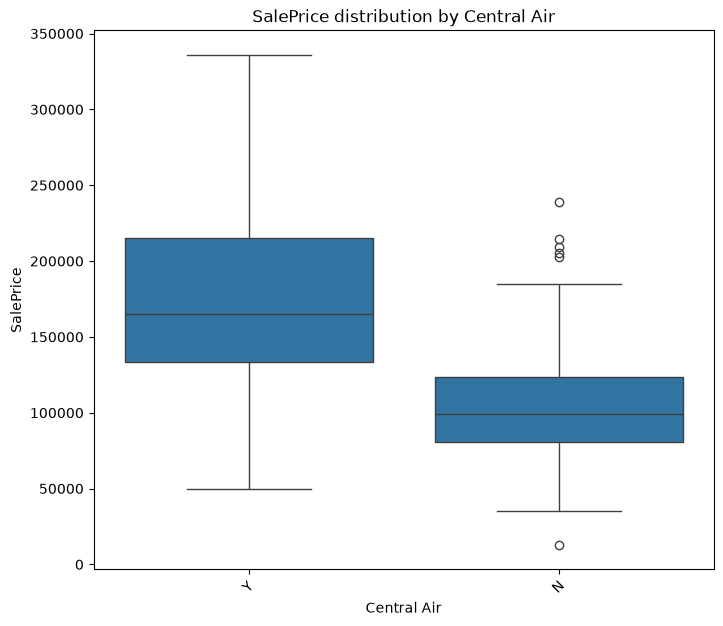

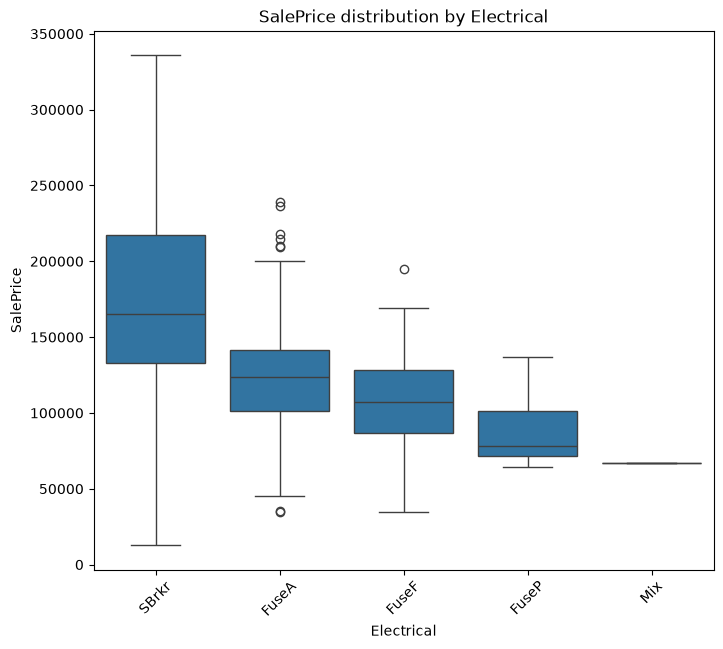

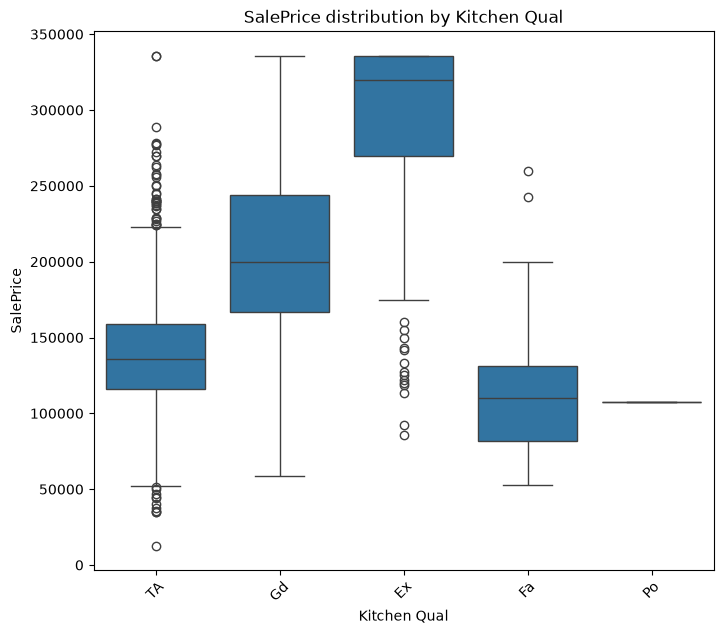

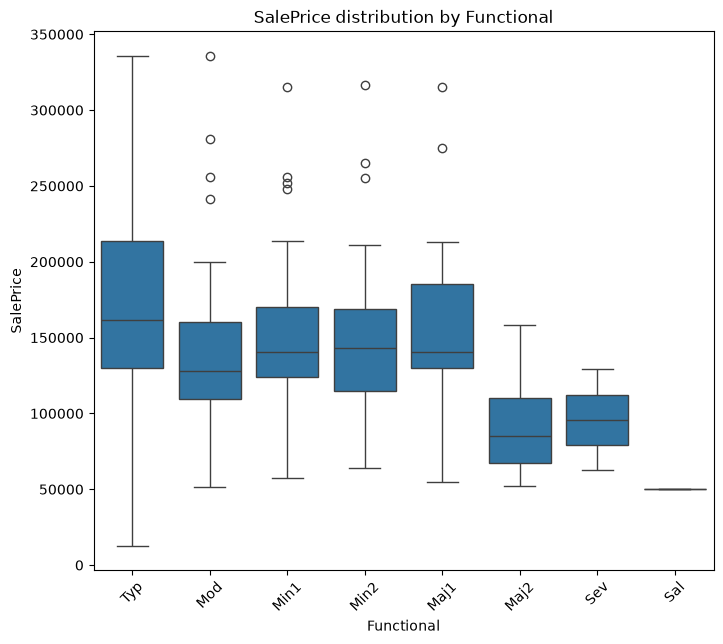

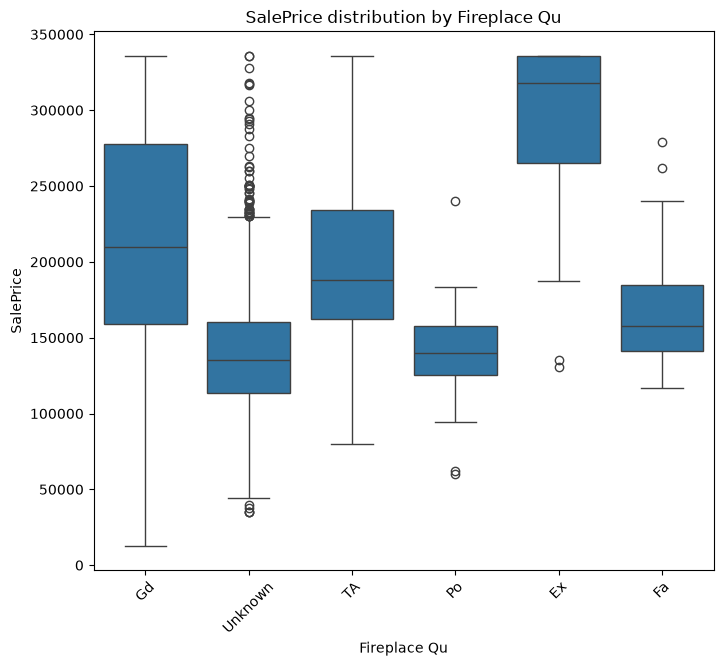

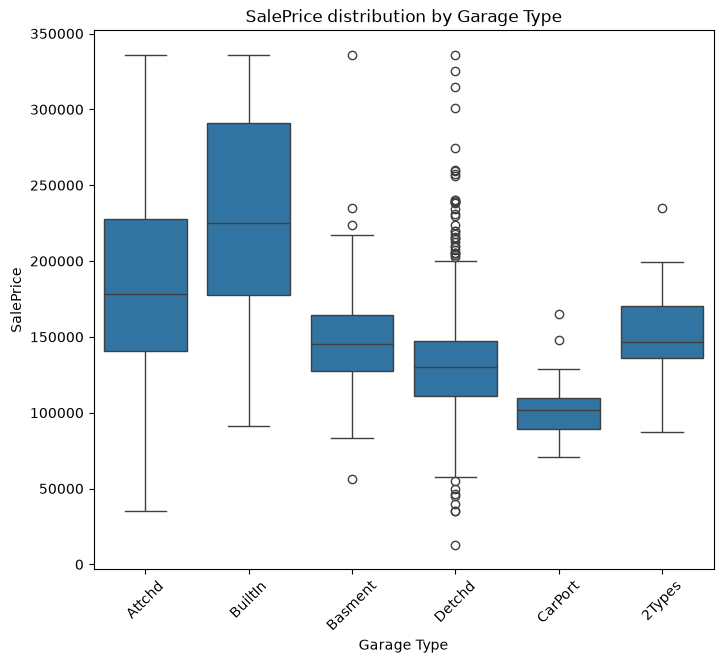

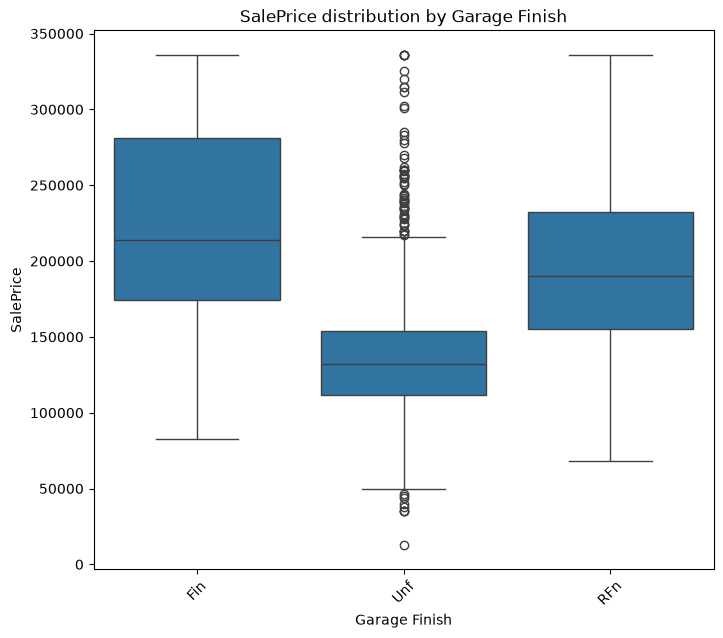

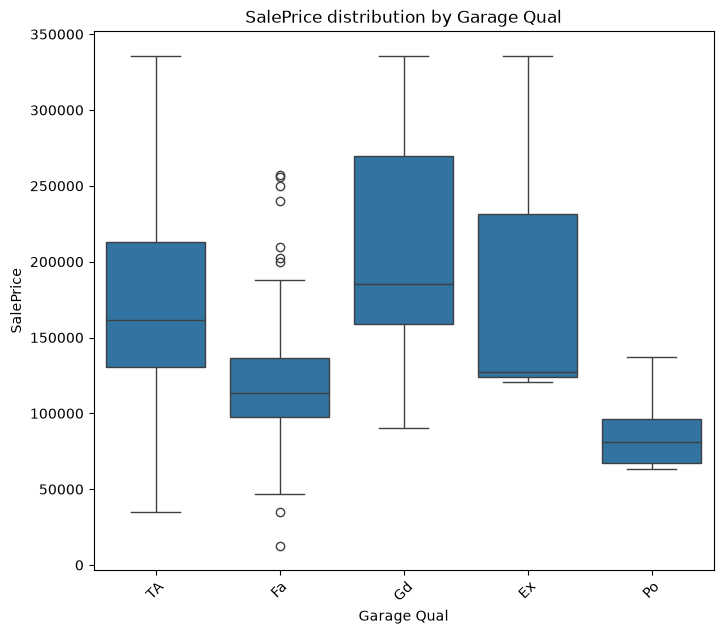

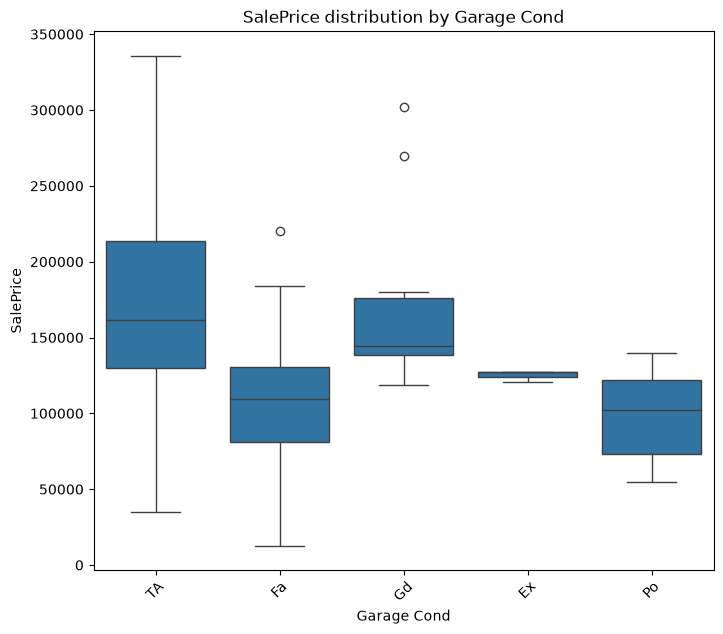

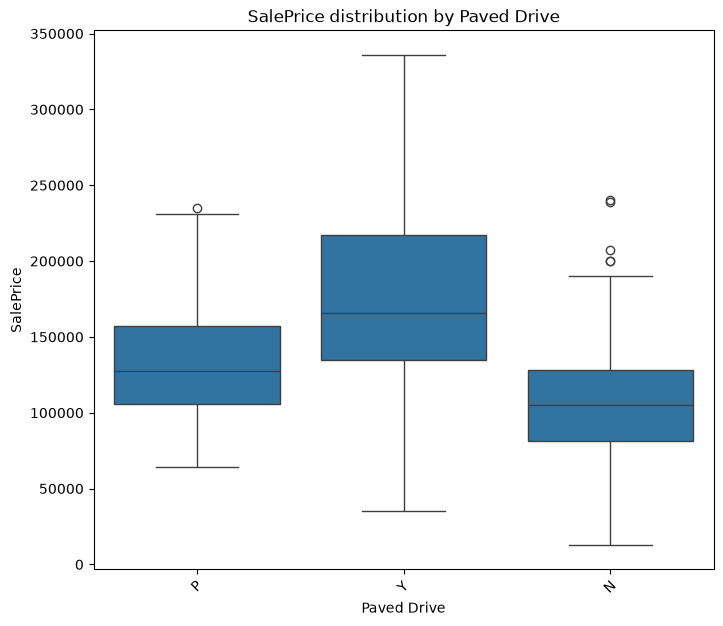

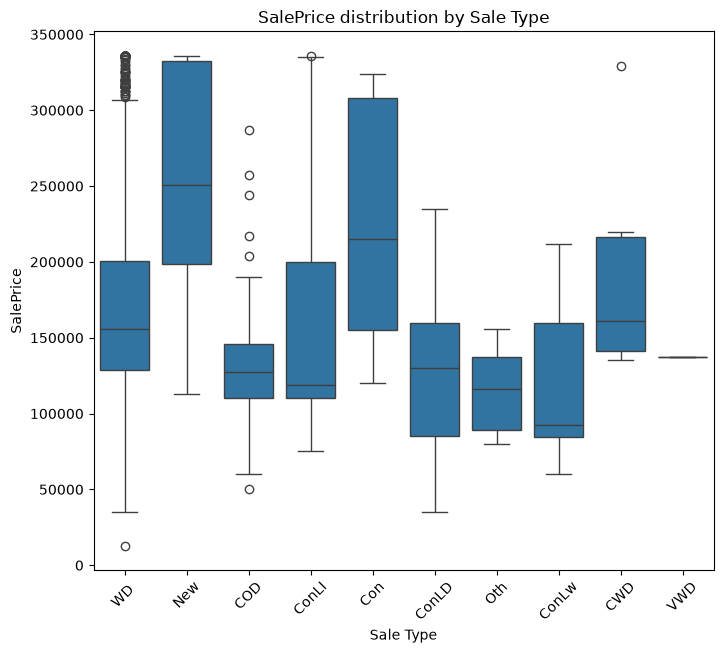

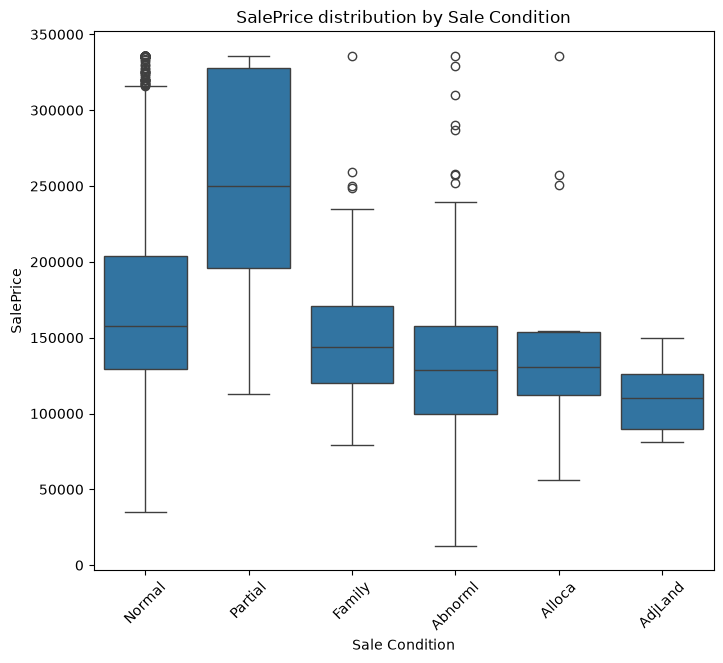

In [196]:
cat_col = dfcopy.select_dtypes(include="str")

for col in cat_col:
    plt.figure(figsize=(8,7))
    sns.boxplot(x=col, y = "SalePrice", data=dfcopy)
    plt.xticks(rotation=45)
    plt.title(f"SalePrice distribution by {col}")    
    plt.show()

### Categorical columns selected are:
- Utilities
- Central Air

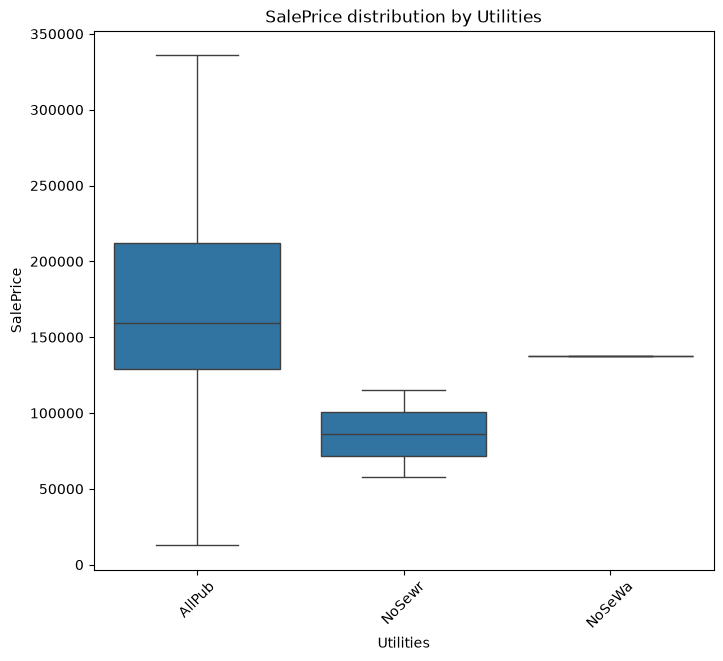

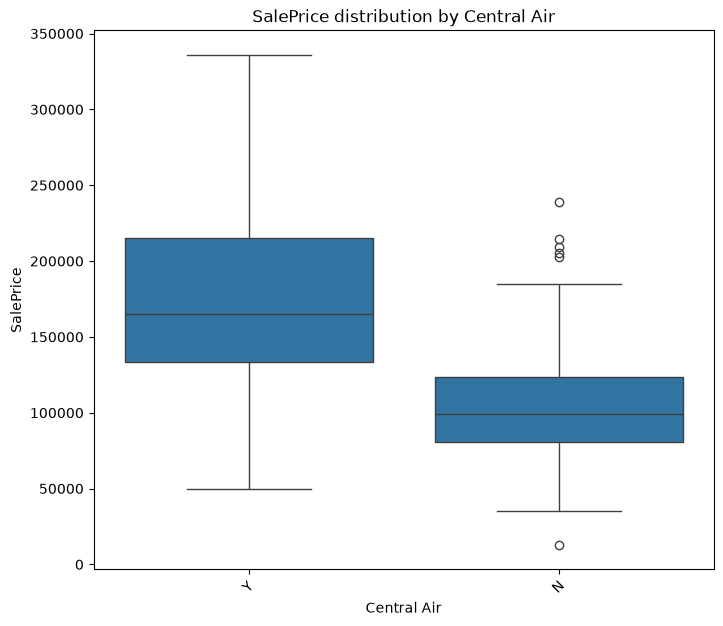

In [197]:
selected_col = ["Utilities", "Central Air"]

for col in selected_col:
    plt.figure(figsize=(8,7))
    sns.boxplot(x=col, y = "SalePrice", data=dfcopy)
    plt.xticks(rotation=45)
    plt.title(f"SalePrice distribution by {col}")    
    plt.show()

### Encoding the columns:
- Central air with label encoding because yes/no
- Utilities with one hot encoding because 3 categories

In [198]:
le = LabelEncoder()

dfcopy["Central Air"] = le.fit_transform(dfcopy["Central Air"])

dfcopy["Central Air"].unique()

array([1, 0])

In [199]:
dfcopy = pd.get_dummies(dfcopy, columns=["Utilities"], drop_first=True)

## Hence Total columns used in multi linear regression are as follows:
- Central Air
- Utilities
- Overall Qual
- Gr Liv Area
- Garage Cars

In [200]:
df_multi = dfcopy[["Central Air", "Utilities_NoSeWa", "Utilities_NoSewr", "Overall Qual", "Gr Liv Area", "Garage Cars"]]

print(df_multi.head())

   Central Air  Utilities_NoSeWa  Utilities_NoSewr  Overall Qual  Gr Liv Area  \
0            1             False             False             6         1656   
1            1             False             False             5          896   
2            1             False             False             6         1329   
3            1             False             False             7         2110   
4            1             False             False             5         1629   

   Garage Cars  
0          2.0  
1          1.0  
2          1.0  
3          2.0  
4          2.0  


In [201]:
X = df_multi
y = dfcopy["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

model = LinearRegression()

model.fit(X_train, y_train)

(2258, 6)
(565, 6)
(2258,)
(565,)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 14088.92,-35521.3 ,-64451.56, 23577.56, 49.46, 18359.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['Central Air','Utilities_NoSeWa','Utilities_NoSewr','Overall Qual', 'Gr Liv Area','Garage Cars']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-8.573e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6


In [202]:
print("Intercept: ", model.intercept_)
print("\n Coefficient: \n", pd.Series(model.coef_, index=X_train.columns))

Intercept:  -85729.94180908997

 Coefficient: 
 Central Air         14088.922117
Utilities_NoSeWa   -35521.301731
Utilities_NoSewr   -64451.556495
Overall Qual        23577.555592
Gr Liv Area            49.463498
Garage Cars         18359.023153
dtype: float64


In [203]:
y_pred = model.predict(X_test)

In [204]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"R²:  {r2:.4f}")
print(f"MAE: {mae:,.2f}")
print(f"MSE: {mse:,.2f}")
print(f"RMSE:{rmse:,.2f}")

R²:  0.8219
MAE: 22,207.20
MSE: 829,612,773.14
RMSE:28,803.00


In [205]:
comparision = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
}).reset_index(drop=True)

print(comparision)

   Actual      Predicted
0  141000  146822.447496
1  258000  289433.375702
2  145000  153277.300629
3  144500  148487.406630
4  179200  170548.126821
5   84900   87029.279144
6   99600   74894.298586
7  230000  242484.450597
8  135000  116443.527522
9  284500  262467.703865


C:\Users\tusha\AppData\Local\Temp\ipykernel_10792\911186455.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


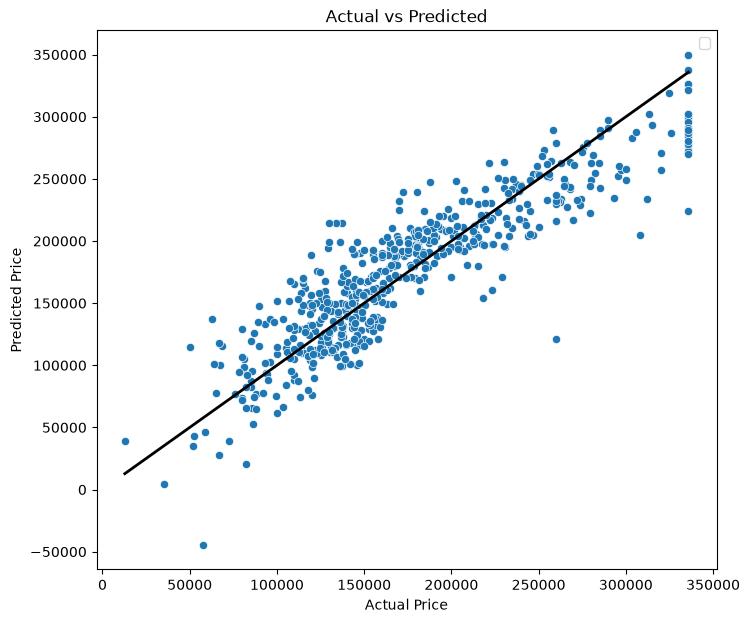

In [206]:
plt.figure(figsize=(8,7))
sns.scatterplot(x=y_test, y=y_pred, s=35)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linewidth=2, color="black")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

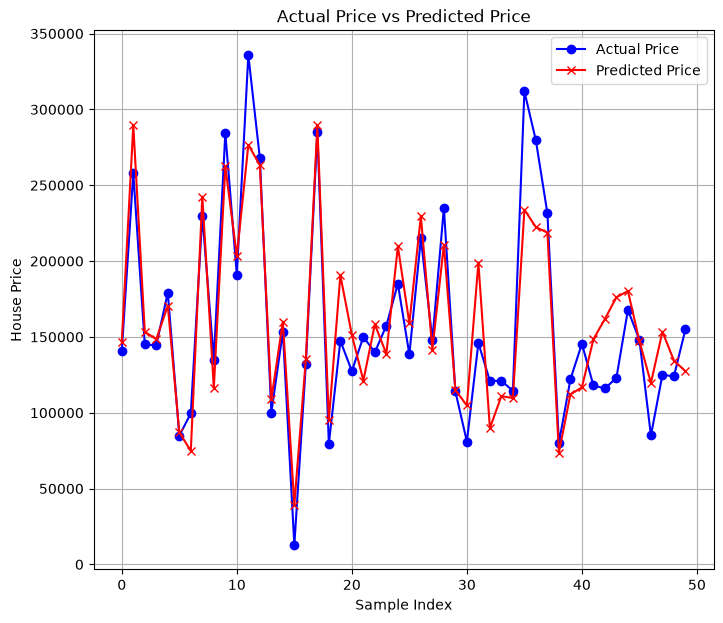

In [207]:
plt.figure(figsize=(8,7))
plt.plot(y_test.values[:50], label="Actual Price", color="blue", marker="o")
plt.plot(y_pred[:50], label="Predicted Price", color="red", marker="x")
plt.title("Actual Price vs Predicted Price")
plt.xlabel("Sample Index")
plt.ylabel("House Price")
plt.legend()
plt.grid(True)
plt.show()